# Load Best Model & Compare with LLM Predictions （GPT3.5）
Standalone notebook — no prior cells needed.

In [ ]:
!pip install pandas numpy scipy networkx tqdm
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
!pip install torch-geometric
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html


PyTorch: 2.10.0+cu128, CUDA: True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 99.6 MB/s eta 0:00:00


In [ ]:
# Restart runtime first, then in the very first cell:
!pip install torch_geometric==2.6.1 -q
!pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.4.0+cu121.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
from tqdm import tqdm
from torch_geometric.nn import RGCNConv
from scipy.sparse import csr_matrix
import scipy.sparse as sp

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/"

nodes = pd.read_csv(DATA_DIR + "nodes.csv")
edges = pd.read_csv(DATA_DIR + "edges.csv")
kg    = pd.read_csv(DATA_DIR + "kg.csv", low_memory=False)

print(f"nodes: {nodes.shape}, kg: {kg.shape}")


Mounted at /content/drive
nodes: (129375, 5), kg: (8100498, 12)


In [ ]:
INDICATION_REL = "indication"
PHENOTYPE_REL  = "disease_phenotype_positive"
DRUG_TYPE      = "drug"
SRC_COL = "x_index"
DST_COL = "y_index"
REL_COL = "relation"

# disease -> phenotypes (undirected)
phen_edges = kg[kg[REL_COL] == PHENOTYPE_REL]
disease_to_phenotypes = defaultdict(set)
for _, row in phen_edges.iterrows():
    disease_to_phenotypes[row[SRC_COL]].add(row[DST_COL])
    disease_to_phenotypes[row[DST_COL]].add(row[SRC_COL])

# drug indices
drug_indices = set(nodes[nodes["node_type"] == DRUG_TYPE]["node_index"].tolist())
drug_indices_arr = np.array(sorted(drug_indices))

# node index <-> name mappings
idx_to_name = dict(zip(nodes["node_index"], nodes["node_name"]))
name_to_idx = dict(zip(nodes["node_name"].str.lower(), nodes["node_index"]))

print(f"Diseases with phenotypes: {len(disease_to_phenotypes)}")
print(f"Drug nodes: {len(drug_indices)}")


Diseases with phenotypes: 16148
Drug nodes: 7957


In [ ]:
train_diseases = set(
    int(x.strip()) for x in open(DATA_DIR + "split/train_disease_ids.txt").readlines()
)
test_diseases = set(
    int(x.strip()) for x in open(DATA_DIR + "split/test_disease_ids.txt").readlines()
)
test_pairs  = pd.read_csv(DATA_DIR + "split/test_drug_pairs.csv")
train_pairs = pd.read_csv(DATA_DIR + "split/train_drug_pairs.csv")

# Test ground truth: disease -> set of true drugs
test_disease_to_drugs = defaultdict(set)
for _, row in test_pairs.iterrows():
    test_disease_to_drugs[int(row["disease_id"])].add(int(row["drug_id"]))

# Train ground truth (for drug degree info)
train_disease_to_drugs = defaultdict(set)
for _, row in train_pairs.iterrows():
    train_disease_to_drugs[int(row["disease_id"])].add(int(row["drug_id"]))

drug_degree = defaultdict(int)
for _, row in train_pairs.iterrows():
    drug_degree[int(row["drug_id"])] += 1

print(f"Train diseases: {len(train_diseases)}, Test diseases: {len(test_diseases)}")
print(f"Test pairs: {len(test_pairs)}")


Train diseases: 431, Test diseases: 108
Test pairs: 1568


In [ ]:
kg_train = kg[
    (~kg[SRC_COL].isin(test_diseases)) &
    (~kg[DST_COL].isin(test_diseases))
]
print(f"kg_train: {len(kg_train)} edges (masked {len(kg) - len(kg_train)})")

# PPR adjacency matrix
N = len(nodes)
src_ppr = kg_train[SRC_COL].values
dst_ppr = kg_train[DST_COL].values
rows = np.concatenate([src_ppr, dst_ppr])
cols = np.concatenate([dst_ppr, src_ppr])
data = np.ones(len(rows), dtype=np.float32)
A = csr_matrix((data, (rows, cols)), shape=(N, N))
row_sums = np.array(A.sum(axis=1)).flatten()
row_sums[row_sums == 0] = 1
D_inv = sp.diags(1.0 / row_sums)
A_norm = D_inv @ A
print(f"PPR adjacency: {A_norm.shape}, nnz={A_norm.nnz:,}")

# PyG graph for R-GCN
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

all_relations = sorted(kg_train["relation"].unique().tolist())
rel2id = {r: i for i, r in enumerate(all_relations)}
NUM_ORIG_RELS = len(rel2id)

src = kg_train["x_index"].values
dst = kg_train["y_index"].values
rel = np.array([rel2id[r] for r in kg_train["relation"].values])

edge_src = np.concatenate([src, dst])
edge_dst = np.concatenate([dst, src])
edge_rel = np.concatenate([rel, rel + NUM_ORIG_RELS])

NUM_RELATIONS = NUM_ORIG_RELS * 2
NUM_NODES = len(nodes)

edge_index = torch.tensor(np.stack([edge_src, edge_dst]), dtype=torch.long).to(DEVICE)
edge_type  = torch.tensor(edge_rel, dtype=torch.long).to(DEVICE)

print(f"Nodes: {NUM_NODES:,}, Edges: {edge_index.shape[1]:,}, Relations: {NUM_RELATIONS}")
print(f"Device: {DEVICE}")


kg_train: 8081958 edges (masked 18540)
PPR adjacency: (129375, 129375), nnz=8,080,782
Nodes: 129,375, Edges: 16,163,916, Relations: 60
Device: cuda


In [ ]:
def recall_at_k(ranked_drugs, true_drugs, k):
    top_k = set(ranked_drugs[:k])
    hits = len(top_k & set(true_drugs))
    return hits / len(true_drugs) if true_drugs else 0.0

def reciprocal_rank(ranked_drugs, true_drugs):
    true_set = set(true_drugs)
    for rank, d in enumerate(ranked_drugs, start=1):
        if d in true_set:
            return 1.0 / rank
    return 0.0

def ppr_scores(seed_indices, A_norm, alpha=0.15, max_iter=50, tol=1e-6):
    N = A_norm.shape[0]
    s = np.zeros(N, dtype=np.float32)
    if len(seed_indices) == 0:
        return s
    s[seed_indices] = 1.0 / len(seed_indices)
    r = s.copy()
    A_T = A_norm.T
    for _ in range(max_iter):
        r_new = (1 - alpha) * A_T.dot(r) + alpha * s
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new
    return r_new

def pad_pheno_batch(pheno_lists, device):
    max_len = max(len(p) for p in pheno_lists)
    batch_size = len(pheno_lists)
    padded = torch.zeros(batch_size, max_len, dtype=torch.long, device=device)
    mask   = torch.ones(batch_size, max_len, dtype=torch.bool, device=device)
    for i, p in enumerate(pheno_lists):
        padded[i, :len(p)] = torch.tensor(p, dtype=torch.long)
        mask[i, :len(p)]   = False
    return padded, mask

print("Metrics and utilities defined.")


Metrics and utilities defined.


In [ ]:
HIDDEN_DIM = 256
NUM_BASES  = 15
NUM_LAYERS = 3
NUM_HEADS  = 4
DROPOUT    = 0.2

class DrugConditionedCrossAttention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)
    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs, key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)

class PhenoDrugModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations, num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention(hidden_dim, num_heads, dropout)
        self.dropout = dropout
    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            residual = x  # ADD THIS LINE
            x = conv(x, edge_index, edge_type)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + residual  # ADD THIS LINE
        return x
    def score(self, node_embs, drug_indices, pheno_indices_list, pheno_mask):
        return self.cross_attn(node_embs[drug_indices], node_embs[pheno_indices_list], pheno_mask)

model = PhenoDrugModel(
    NUM_NODES, NUM_RELATIONS, HIDDEN_DIM, NUM_BASES, NUM_LAYERS, NUM_HEADS, DROPOUT
).to(DEVICE)

model.load_state_dict(torch.load(DATA_DIR + "best_model.pt", map_location=DEVICE))
model.eval()
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")


Model loaded: 36,534,157 parameters


In [ ]:
print("Scoring all test diseases...")
all_results = {}  # disease_idx -> {model_scores, ppr_scores, ensemble_scores, ranked_drugs}

with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)
    for disease_idx in tqdm(test_diseases, desc="Scoring"):
        phenos = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = list(test_disease_to_drugs.get(disease_idx, []))
        if not phenos or not true_drugs:
            continue

        # Model scores
        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        model_scores = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs + 512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([phenos] * (ce - cs), DEVICE)
            model_scores.append(model.score(node_embs_eval, all_drugs_t[cs:ce], cp, cm).cpu().numpy())
        model_scores = np.concatenate(model_scores)

        # PPR scores
        ppr = ppr_scores(phenos, A_norm, alpha=0.15)
        ppr_drug_scores = ppr[drug_indices_arr]

        # Ensemble (w=0.9 model, 0.1 PPR)
        ms = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)
        ps = (ppr_drug_scores - ppr_drug_scores.min()) / (ppr_drug_scores.max() - ppr_drug_scores.min() + 1e-8)
        combined = 0.9 * ms + 0.1 * ps

        all_results[disease_idx] = {
            "model_scores": model_scores,
            "ppr_scores": ppr_drug_scores,
            "ensemble_scores": combined,
            "true_drugs": true_drugs,
            "phenos": phenos,
            "ranked_model": drug_indices_arr[np.argsort(-model_scores)].tolist(),
            "ranked_ppr": drug_indices_arr[np.argsort(-ppr_drug_scores)].tolist(),
            "ranked_ensemble": drug_indices_arr[np.argsort(-combined)].tolist(),
        }

print(f"Scored {len(all_results)} test diseases.")


Scoring all test diseases...


Scoring: 100%|██████████| 108/108 [01:35<00:00,  1.13it/s]

Scored 108 test diseases.


In [ ]:
# *** CHANGE THIS PATH to your actual JSON file ***
LLM_JSON_PATH = '/content/drive/MyDrive/Colab Notebooks/split/llm_baseline_results_35.json'

with open(LLM_JSON_PATH) as f:
    llm_raw = json.load(f)

# Print structure to understand format
print(f"Type: {type(llm_raw)}")
if isinstance(llm_raw, dict):
    print(f"Keys: {list(llm_raw.keys())[:5]}")
    first_key = list(llm_raw.keys())[0]
    print(f"First entry ({first_key}): {type(llm_raw[first_key])}")
    if isinstance(llm_raw[first_key], list):
        print(f"  First 3 items: {llm_raw[first_key][:3]}")
    elif isinstance(llm_raw[first_key], dict):
        print(f"  Keys: {list(llm_raw[first_key].keys())[:5]}")
elif isinstance(llm_raw, list):
    print(f"Length: {len(llm_raw)}")
    print(f"First entry: {llm_raw[0]}")


for k, v in llm_raw.items():
    print(f"{k}: {type(v)} = {str(v)[:200]}")


Type: <class 'dict'>
Keys: ['model', 'n_drugs_requested', 'n_evaluated', 'mrr', 'recalls']
First entry (model): <class 'str'>
model: <class 'str'> = gpt-3.5-turbo-0125
n_drugs_requested: <class 'int'> = 50
n_evaluated: <class 'int'> = 108
mrr: <class 'float'> = 0.3204231551906673
recalls: <class 'dict'> = {'1': 0.07062573644768658, '5': 0.16196767203486065, '10': 0.2362657227666563, '20': 0.3350065685351168, '50': 0.5308423153926618}
per_disease: <class 'list'> = [{'disease_idx': 27219, 'suggested_drugs': ['testosterone', 'clomiphene', 'gonadorelin', 'hCG', 'letrozole', 'anastrozole', 'estradiol', 'leuprolide', 'follicle stimulating hormone', 'luteinizing horm


In [ ]:
# Build llm_results from the per_disease structure (your JSON format)
llm_results = {}
drug_nodes_df = nodes[nodes["node_type"] == "drug"][["node_index", "node_name"]].copy()
drug_nodes_df["name_lower"] = drug_nodes_df["node_name"].str.lower().str.strip()
drug_name_to_idx = dict(zip(drug_nodes_df["name_lower"], drug_nodes_df["node_index"]))

for entry in llm_raw['per_disease']:
    d_idx = entry['disease_idx']
    drug_names = entry['suggested_drugs']
    matched_indices = []
    for name in drug_names:
        clean = str(name).lower().strip()
        if clean in drug_name_to_idx:
            matched_indices.append(drug_name_to_idx[clean])
    llm_results[d_idx] = matched_indices

print(f"Built llm_results for {len(llm_results)} diseases")
print(f"Avg drugs matched: {np.mean([len(v) for v in llm_results.values()]):.1f}")

Built llm_results for 108 diseases
Avg drugs matched: 35.6


In [ ]:
# ── CELL 10: Parse LLM Predictions ──────────────────────────────────────────
llm_results = {}

# Build flexible name matcher (lowercase, strip whitespace)
drug_nodes_df = nodes[nodes["node_type"] == "drug"][["node_index", "node_name"]].copy()
drug_nodes_df["name_lower"] = drug_nodes_df["node_name"].str.lower().str.strip()
drug_name_to_idx = dict(zip(drug_nodes_df["name_lower"], drug_nodes_df["node_index"]))

unmatched_all = []

for entry in llm_raw["per_disease"]:
    d_idx = int(entry["disease_idx"])
    if d_idx not in test_diseases:
        continue

    ranked_drugs = []
    unmatched = []
    for dname in entry["suggested_drugs"]:
        dname_clean = dname.lower().strip()
        match = drug_name_to_idx.get(dname_clean)
        if match is not None:
            ranked_drugs.append(match)
        else:
            unmatched.append(dname)
            unmatched_all.append(dname)

    llm_results[d_idx] = ranked_drugs

print(f"LLM predictions parsed: {len(llm_results)} test diseases")
print(f"Avg drugs matched per disease: {np.mean([len(v) for v in llm_results.values()]):.1f} / 50")
print(f"Total unmatched drug names: {len(unmatched_all)}")

# Show most common unmatched names (need fuzzy matching?)
from collections import Counter
common_unmatched = Counter(unmatched_all).most_common(15)
print(f"\nTop unmatched drug names:")
for name, count in common_unmatched:
    print(f"  {count:3d}x  {name}")

LLM predictions parsed: 108 test diseases
Avg drugs matched per disease: 35.6 / 50
Total unmatched drug names: 1997

Top unmatched drug names:
  382x  budesonide/formoterol
   99x  dorzolamide-timolol maleate hydrochloride
   54x  Antiemetics
   51x  dorzolamide-timolol hydrochloride
   50x  dorzolamide hydrochloride-timolol maleate
   50x  dorzolamide hydrochloride-timolol
   40x  Antifibrinolytics
   39x  esomeprazole/naproxen
   29x  azelastine-fluticasone
   20x  octreotide acetate
   20x  somatostatin acetate
   19x  Zicronapine
   14x  alendronate
   14x  L-ornithine-L-aspartate
   11x  risedronate


In [ ]:
# Quick sanity check — what MRR does this checkpoint actually give?
with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)
    quick_results = []
    for d in test_diseases:
        ph = list(disease_to_phenotypes.get(d, []))
        td = list(test_disease_to_drugs.get(d, []))
        if not ph or not td: continue
        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            sc.append(model.score(node_embs_eval, ad[cs:ce], cp, cm).cpu().numpy())
        sc = np.concatenate(sc)
        rd = drug_indices_arr[np.argsort(-sc)].tolist()
        quick_results.append({"MRR": reciprocal_rank(rd, td), "R@10": recall_at_k(rd, td, 10)})

qdf = pd.DataFrame(quick_results)
print(f"This checkpoint: MRR={qdf['MRR'].mean():.4f}, R@10={qdf['R@10'].mean():.4f}")

This checkpoint: MRR=0.1995, R@10=0.1739


In [ ]:
from sklearn.metrics import roc_auc_score

comparison = []
for d_idx in sorted(all_results.keys()):
    res = all_results[d_idx]
    true_drugs = res["true_drugs"]
    d_name = idx_to_name.get(d_idx, str(d_idx))

    row = {
        "disease": d_idx,
        "disease_name": d_name,
        "n_phenos": len(res["phenos"]),
        "n_true_drugs": len(true_drugs),
    }

    # R-GCN model
    for method, ranked in [("model", res["ranked_model"]),
                           ("ppr", res["ranked_ppr"]),
                           ("ensemble", res["ranked_ensemble"])]:
        row[f"{method}_MRR"] = reciprocal_rank(ranked, true_drugs)
        row[f"{method}_R@1"] = recall_at_k(ranked, true_drugs, 1)
        row[f"{method}_R@5"] = recall_at_k(ranked, true_drugs, 5)
        row[f"{method}_R@10"] = recall_at_k(ranked, true_drugs, 10)
        row[f"{method}_R@50"] = recall_at_k(ranked, true_drugs, 50)

    # LLM (if available for this disease)
    if d_idx in llm_results:
        llm_ranked = llm_results[d_idx]
        # LLM only returns a partial list — drugs not mentioned get worst rank
        # Append all unranked drugs at the end
        llm_mentioned = set(llm_ranked)
        llm_full = llm_ranked + [d for d in drug_indices_arr if d not in llm_mentioned]
        row["llm_MRR"] = reciprocal_rank(llm_full, true_drugs)
        row["llm_R@1"] = recall_at_k(llm_full, true_drugs, 1)
        row["llm_R@5"] = recall_at_k(llm_full, true_drugs, 5)
        row["llm_R@10"] = recall_at_k(llm_full, true_drugs, 10)
        row["llm_R@50"] = recall_at_k(llm_full, true_drugs, 50)
        row["llm_n_drugs_returned"] = len(llm_ranked)
    else:
        row["llm_MRR"] = None

    comparison.append(row)

comp_df = pd.DataFrame(comparison)

# ── Summary table ──
print("=" * 70)
print("METHOD COMPARISON (mean over test diseases)")
print("=" * 70)
methods = ["ppr", "model", "ensemble"]
if comp_df["llm_MRR"].notna().any():
    methods.append("llm")

for method in methods:
    cols = [c for c in comp_df.columns if c.startswith(f"{method}_")]
    means = comp_df[cols].mean()
    label = {"ppr": "PPR", "model": "R-GCN+CrossAttn", "ensemble": "Ensemble (w=0.9)",
             "llm": "LLM Standalone"}.get(method, method)
    print(f"\n  {label}:")
    for col in cols:
        metric = col.replace(f"{method}_", "")
        print(f"    {metric:<8s}: {means[col]:.4f}")


METHOD COMPARISON (mean over test diseases)

  PPR:
    MRR     : 0.1054
    R@1     : 0.0087
    R@5     : 0.0418
    R@10    : 0.0685
    R@50    : 0.1605

  R-GCN+CrossAttn:
    MRR     : 0.1997
    R@1     : 0.0572
    R@5     : 0.1257
    R@10    : 0.1739
    R@50    : 0.3342

  Ensemble (w=0.9):
    MRR     : 0.2268
    R@1     : 0.0725
    R@5     : 0.1500
    R@10    : 0.1905
    R@50    : 0.3574

  LLM Standalone:
    MRR     : 0.3361
    R@1     : 0.0880
    R@5     : 0.1972
    R@10    : 0.2449
    R@50    : 0.3484
    n_drugs_returned: 35.6296


In [ ]:
if comp_df["llm_MRR"].notna().any():
    llm_df = comp_df[comp_df["llm_MRR"].notna()].copy()

    print(f"\nDiseases with both model and LLM predictions: {len(llm_df)}")

    # Where does LLM beat model?
    llm_df["llm_wins"] = llm_df["llm_MRR"] > llm_df["ensemble_MRR"]
    llm_df["model_wins"] = llm_df["ensemble_MRR"] > llm_df["llm_MRR"]
    llm_df["tie"] = llm_df["llm_MRR"] == llm_df["ensemble_MRR"]

    print(f"\nLLM wins: {llm_df['llm_wins'].sum()}")
    print(f"Model wins: {llm_df['model_wins'].sum()}")
    print(f"Ties: {llm_df['tie'].sum()}")

    # Cases where LLM wins big
    print("\n── Cases where LLM beats model by largest margin ──")
    llm_df["mrr_diff"] = llm_df["llm_MRR"] - llm_df["ensemble_MRR"]
    for _, row in llm_df.nlargest(5, "mrr_diff").iterrows():
        print(f"  {row['disease_name']}: LLM MRR={row['llm_MRR']:.3f} vs Model={row['ensemble_MRR']:.3f} "
              f"(+{row['mrr_diff']:.3f}), phenos={row['n_phenos']}")

    # Cases where model wins big
    print("\n── Cases where model beats LLM by largest margin ──")
    for _, row in llm_df.nsmallest(5, "mrr_diff").iterrows():
        print(f"  {row['disease_name']}: Model MRR={row['ensemble_MRR']:.3f} vs LLM={row['llm_MRR']:.3f} "
              f"({row['mrr_diff']:.3f}), phenos={row['n_phenos']}")

    # By phenotype count
    print("\n── MRR by phenotype count ──")
    llm_df["pheno_bin"] = pd.cut(llm_df["n_phenos"], bins=[0,3,10,30,200],
                                  labels=["1-3","4-10","11-30","30+"])
    print(llm_df.groupby("pheno_bin")[["ensemble_MRR","llm_MRR"]].mean().round(4))

    # Cold-start analysis: does LLM help when true drugs aren't in training?
    print("\n── Cold-start analysis ──")
    llm_df["cold_start"] = llm_df["disease"].apply(
        lambda d: all(drug_degree.get(td, 0) == 0
                      for td in test_disease_to_drugs.get(d, []))
    )
    for is_cold, label in [(True, "Cold-start"), (False, "Warm")]:
        sub = llm_df[llm_df["cold_start"] == is_cold]
        if len(sub) > 0:
            print(f"  {label} ({len(sub)} diseases): "
                  f"Model MRR={sub['ensemble_MRR'].mean():.4f}, "
                  f"LLM MRR={sub['llm_MRR'].mean():.4f}")



Diseases with both model and LLM predictions: 108

LLM wins: 53
Model wins: 48
Ties: 7

── Cases where LLM beats model by largest margin ──
  Leber hereditary optic neuropathy: LLM MRR=1.000 vs Model=0.000 (+1.000), phenos=21
  blepharospasm: LLM MRR=1.000 vs Model=0.000 (+1.000), phenos=4
  retinopathy of prematurity: LLM MRR=1.000 vs Model=0.000 (+1.000), phenos=7
  phaeochromocytoma: LLM MRR=1.000 vs Model=0.001 (+0.999), phenos=14
  obsolete neurogenic bladder (disease): LLM MRR=1.000 vs Model=0.004 (+0.996), phenos=1

── Cases where model beats LLM by largest margin ──
  Wolman disease: Model MRR=1.000 vs LLM=0.000 (-1.000), phenos=15
  Glanzmann thrombasthenia: Model MRR=1.000 vs LLM=0.000 (-1.000), phenos=19
  narcolepsy-cataplexy syndrome: Model MRR=1.000 vs LLM=0.002 (-0.998), phenos=9
  short stature due to growth hormone qualitative anomaly: Model MRR=1.000 vs LLM=0.005 (-0.995), phenos=5
  shigellosis: Model MRR=1.000 vs LLM=0.006 (-0.994), phenos=37

── MRR by phenotype c

/tmp/ipykernel_1133/7087868.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(llm_df.groupby("pheno_bin")[["ensemble_MRR","llm_MRR"]].mean().round(4))


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# FIX: Add off-label links to test ground truth (CRITICAL!)
# ═══════════════════════════════════════════════════════════════════════

print("Adding off-label links to test ground truth...")
print("="*80)

# Check original test pairs
original_count = sum(len(v) for v in test_disease_to_drugs.values())
print(f"Original test ground truth pairs: {original_count}")

# Add off-label uses from the FULL kg (not just kg_train)
offlabel_test = kg[kg["relation"] == "off-label use"]
print(f"Total off-label edges in kg: {len(offlabel_test)}")

added_count = 0
for _, row in offlabel_test.iterrows():
    d_idx = int(row["y_index"])  # disease
    drug = int(row["x_index"])   # drug

    # Only add if disease is in test set and drug is a valid drug node
    if d_idx in test_diseases and drug in drug_indices:
        test_disease_to_drugs[d_idx].add(drug)
        added_count += 1

new_count = sum(len(v) for v in test_disease_to_drugs.values())
print(f"Added {added_count} off-label links")
print(f"New test ground truth pairs: {new_count}")
print(f"✅ Test ground truth now includes off-label uses")

# Verify one disease
sample_d = sorted(test_diseases)[0]
print(f"\nExample - Disease {sample_d}:")
print(f"  True drugs (with off-label): {len(test_disease_to_drugs[sample_d])}")

Adding off-label links to test ground truth...
Original test ground truth pairs: 784
Total off-label edges in kg: 5136
Added 143 off-label links
New test ground truth pairs: 914
✅ Test ground truth now includes off-label uses

Example - Disease 27219:
  True drugs (with off-label): 2


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# COMPARISON: Evaluate WITH and WITHOUT off-label links
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("COMPARING: Test Ground Truth WITH vs WITHOUT Off-Label")
print("="*80)

# Save current state (without off-label)
test_disease_to_drugs_backup = {k: v.copy() for k, v in test_disease_to_drugs.items()}

# ──────────────────────────────────────────────────────────────────────
# STEP 1: Evaluate WITHOUT off-label (current state)
# ──────────────────────────────────────────────────────────────────────
print("\n1. Evaluating WITHOUT off-label links...")
print("─"*80)

model.load_state_dict(torch.load(DATA_DIR + "best_model.pt", map_location=DEVICE))
model.eval()

with torch.no_grad():
    ne = model.encode(edge_index, edge_type)

    results_without_offlabel = []
    for d in tqdm(test_diseases, desc="Without off-label", leave=False):
        ph = list(disease_to_phenotypes.get(d, []))
        td = list(test_disease_to_drugs.get(d, []))
        if not ph or not td:
            continue

        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
        sc = np.concatenate(sc)
        rd = drug_indices_arr[np.argsort(-sc)].tolist()

        results_without_offlabel.append({
            "disease": d,
            "MRR": reciprocal_rank(rd, td),
            "R@10": recall_at_k(rd, td, 10),
            "n_true": len(td),
        })

df_without = pd.DataFrame(results_without_offlabel)
print(f"✓ Evaluated {len(df_without)} diseases")
print(f"  Total true drugs: {df_without['n_true'].sum()}")
print(f"  MRR:  {df_without['MRR'].mean():.4f}")
print(f"  R@10: {df_without['R@10'].mean():.4f}")

# ──────────────────────────────────────────────────────────────────────
# STEP 2: Add off-label links to ground truth
# ──────────────────────────────────────────────────────────────────────
print("\n2. Adding off-label links to test ground truth...")
print("─"*80)

offlabel_test = kg[kg["relation"] == "off-label use"]
print(f"Total off-label edges in kg: {len(offlabel_test)}")

added_by_disease = defaultdict(int)
for _, row in offlabel_test.iterrows():
    d_idx = int(row["y_index"])  # disease
    drug = int(row["x_index"])   # drug

    if d_idx in test_diseases and drug in drug_indices:
        if drug not in test_disease_to_drugs[d_idx]:
            test_disease_to_drugs[d_idx].add(drug)
            added_by_disease[d_idx] += 1

print(f"✓ Added off-label to {len(added_by_disease)} diseases")
print(f"  Total off-label links added: {sum(added_by_disease.values())}")
print(f"  New total true drugs: {sum(len(v) for v in test_disease_to_drugs.values())}")

# ──────────────────────────────────────────────────────────────────────
# STEP 3: Evaluate WITH off-label links
# ──────────────────────────────────────────────────────────────────────
print("\n3. Evaluating WITH off-label links...")
print("─"*80)

with torch.no_grad():
    ne = model.encode(edge_index, edge_type)

    results_with_offlabel = []
    for d in tqdm(test_diseases, desc="With off-label", leave=False):
        ph = list(disease_to_phenotypes.get(d, []))
        td = list(test_disease_to_drugs.get(d, []))
        if not ph or not td:
            continue

        ad = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        sc = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs+512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([ph]*(ce-cs), DEVICE)
            sc.append(model.score(ne, ad[cs:ce], cp, cm).cpu().numpy())
        sc = np.concatenate(sc)
        rd = drug_indices_arr[np.argsort(-sc)].tolist()

        results_with_offlabel.append({
            "disease": d,
            "MRR": reciprocal_rank(rd, td),
            "R@10": recall_at_k(rd, td, 10),
            "n_true": len(td),
        })

df_with = pd.DataFrame(results_with_offlabel)
print(f"✓ Evaluated {len(df_with)} diseases")
print(f"  Total true drugs: {df_with['n_true'].sum()}")
print(f"  MRR:  {df_with['MRR'].mean():.4f}")
print(f"  R@10: {df_with['R@10'].mean():.4f}")

# ──────────────────────────────────────────────────────────────────────
# STEP 4: Side-by-side comparison
# ──────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("COMPARISON RESULTS")
print("="*80)

comparison = pd.DataFrame({
    "Metric": ["MRR", "R@10", "Total True Drugs"],
    "WITHOUT Off-Label": [
        df_without['MRR'].mean(),
        df_without['R@10'].mean(),
        df_without['n_true'].sum()
    ],
    "WITH Off-Label": [
        df_with['MRR'].mean(),
        df_with['R@10'].mean(),
        df_with['n_true'].sum()
    ],
})
comparison["Difference"] = comparison["WITH Off-Label"] - comparison["WITHOUT Off-Label"]
comparison["% Change"] = 100 * comparison["Difference"] / comparison["WITHOUT Off-Label"]

print(comparison.to_string(index=False))

# Show diseases with biggest improvement
print("\n" + "="*80)
print("Diseases with biggest MRR improvement from off-label:")
print("="*80)

merged = df_without.merge(df_with, on="disease", suffixes=("_without", "_with"))
merged["MRR_gain"] = merged["MRR_with"] - merged["MRR_without"]
merged = merged[merged["MRR_gain"] > 0].sort_values("MRR_gain", ascending=False)

for idx, row in merged.head(10).iterrows():
    d_name = idx_to_name.get(row["disease"], str(row["disease"]))[:50]
    n_added = row["n_true_with"] - row["n_true_without"]
    print(f"{d_name:50s}  +{row['MRR_gain']:.4f}  ({n_added} off-label drugs added)")

# Final verdict
print("\n" + "="*80)
print("VERDICT")
print("="*80)

if df_with['MRR'].mean() > df_without['MRR'].mean() * 1.2:
    print(f"✅ Off-label links significantly improve MRR (+{(df_with['MRR'].mean() - df_without['MRR'].mean()):.4f})")
    print(f"   This explains the discrepancy!")
    print(f"\n   Pagerank (3) includes off-label:    MRR ≈ {df_with['MRR'].mean():.4f}")
    print(f"   Load_and_Compare (1) missing them:  MRR ≈ {df_without['MRR'].mean():.4f}")
elif df_with['MRR'].mean() > df_without['MRR'].mean():
    print(f"⚠️  Off-label links only slightly improve MRR (+{(df_with['MRR'].mean() - df_without['MRR'].mean()):.4f})")
    print(f"   This does NOT fully explain the discrepancy.")
else:
    print(f"ℹ️  Off-label links don't improve MRR")
    print(f"   The discrepancy must be due to something else.")

# Restore backup if you want to test without off-label again
# test_disease_to_drugs = test_disease_to_drugs_backup

COMPARING: Test Ground Truth WITH vs WITHOUT Off-Label

1. Evaluating WITHOUT off-label links...
────────────────────────────────────────────────────────────────────────────────


✓ Evaluated 108 diseases
  Total true drugs: 914
  MRR:  0.2537
  R@10: 0.1874

2. Adding off-label links to test ground truth...
────────────────────────────────────────────────────────────────────────────────
Total off-label edges in kg: 5136
✓ Added off-label to 0 diseases
  Total off-label links added: 0
  New total true drugs: 914

3. Evaluating WITH off-label links...
────────────────────────────────────────────────────────────────────────────────


✓ Evaluated 108 diseases
  Total true drugs: 914
  MRR:  0.2538
  R@10: 0.1874

COMPARISON RESULTS
          Metric  WITHOUT Off-Label  WITH Off-Label  Difference  % Change
             MRR            0.25367        0.253795    0.000125  0.049309
            R@10            0.18736        0.187360    0.000000  0.000000
Total True Drugs          914.00000      914.000000    0.000000  0.000000

Diseases with biggest MRR improvement from off-label:
atopic conjunctivitis                               +0.0210  (0.0 off-label drugs added)
nonpapillary renal cell carcinoma                   +0.0000  (0.0 off-label drugs added)

VERDICT
⚠️  Off-label links only slightly improve MRR (+0.0001)
   This does NOT fully explain the discrepancy.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# DIAGNOSE: Why Cell 12 (MRR=0.20) ≠ Cell 16 (MRR=0.25)?
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("COMPARING Cell 9/12 (MRR=0.20) vs Cell 16 (MRR=0.25)")
print("="*80)

# ──────────────────────────────────────────────────────────────────────
# Check 1: What's in all_results from Cell 9?
# ──────────────────────────────────────────────────────────────────────
print("\n1. Checking all_results from Cell 9")
print("─"*80)

# Cell 9 stored the true_drugs at that moment
sample_disease = sorted(all_results.keys())[0]
print(f"Sample disease {sample_disease}:")
print(f"  all_results true_drugs: {len(all_results[sample_disease]['true_drugs'])}")
print(f"  Current test_disease_to_drugs: {len(test_disease_to_drugs[sample_disease])}")
print(f"  Match: {set(all_results[sample_disease]['true_drugs']) == test_disease_to_drugs[sample_disease]}")

# Count across all diseases
total_in_all_results = sum(len(res['true_drugs']) for res in all_results.values())
total_in_current = sum(len(test_disease_to_drugs[d]) for d in all_results.keys())
print(f"\nTotal drugs:")
print(f"  Stored in all_results (Cell 9): {total_in_all_results}")
print(f"  Current test_disease_to_drugs:  {total_in_current}")
print(f"  Difference: {total_in_current - total_in_all_results}")

# ──────────────────────────────────────────────────────────────────────
# Check 2: Re-compute MRR from all_results using CURRENT ground truth
# ──────────────────────────────────────────────────────────────────────
print("\n2. Re-computing metrics from Cell 9 scores with CURRENT ground truth")
print("─"*80)

recomputed = []
for d_idx, res in all_results.items():
    # Use current test_disease_to_drugs (might have more drugs now)
    current_true = list(test_disease_to_drugs[d_idx])

    # Use the rankings from Cell 9
    ranked_model = res["ranked_model"]

    recomputed.append({
        "MRR_old": reciprocal_rank(ranked_model, res["true_drugs"]),  # Original
        "MRR_new": reciprocal_rank(ranked_model, current_true),       # With current truth
        "n_true_old": len(res["true_drugs"]),
        "n_true_new": len(current_true),
    })

recomp_df = pd.DataFrame(recomputed)
print(f"MRR with old ground truth (Cell 9):    {recomp_df['MRR_old'].mean():.4f}")
print(f"MRR with current ground truth:         {recomp_df['MRR_new'].mean():.4f}")
print(f"Difference: {recomp_df['MRR_new'].mean() - recomp_df['MRR_old'].mean():.4f}")
print(f"\nAvg true drugs per disease:")
print(f"  Old (Cell 9): {recomp_df['n_true_old'].mean():.1f}")
print(f"  Current:      {recomp_df['n_true_new'].mean():.1f}")
print(f"  Added:        {recomp_df['n_true_new'].mean() - recomp_df['n_true_old'].mean():.1f}")

# ──────────────────────────────────────────────────────────────────────
# Check 3: Which diseases got additional drugs?
# ──────────────────────────────────────────────────────────────────────
print("\n3. Diseases that gained drugs")
print("─"*80)

diseases_with_additions = recomp_df[recomp_df['n_true_new'] > recomp_df['n_true_old']]
print(f"Diseases with additional drugs: {len(diseases_with_additions)} / {len(recomp_df)}")

if len(diseases_with_additions) > 0:
    print("\nDiseases with biggest MRR gain:")
    mrr_gains = recomp_df[recomp_df['MRR_new'] > recomp_df['MRR_old']].copy()
    mrr_gains['gain'] = mrr_gains['MRR_new'] - mrr_gains['MRR_old']
    mrr_gains = mrr_gains.nlargest(10, 'gain')

    for idx, row in mrr_gains.iterrows():
        d_idx = list(all_results.keys())[idx]
        d_name = idx_to_name.get(d_idx, str(d_idx))[:45]
        print(f"  {d_name:45s}  +{row['gain']:.4f}  ({int(row['n_true_new'] - row['n_true_old'])} drugs added)")

# ──────────────────────────────────────────────────────────────────────
# CONCLUSION
# ──────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

if recomp_df['MRR_new'].mean() > recomp_df['MRR_old'].mean() + 0.03:
    print("✅ test_disease_to_drugs was MODIFIED between Cell 9 and Cell 16")
    print(f"   - Cell 9/12/13: Used ground truth with {total_in_all_results} drugs → MRR=0.1995")
    print(f"   - Cell 16: Used ground truth with {total_in_current} drugs → MRR=0.2536")
    print(f"   - Difference: {total_in_current - total_in_all_results} additional drugs")
    print("\n   Something added ~{} drugs between Cell 9 and Cell 16".format(total_in_current - total_in_all_results))
    print("   Likely candidates:")
    print("   • test_pairs.csv was reloaded with more data")
    print("   • Off-label links were added (even though Cell 15 said 0)")
    print("   • test_disease_to_drugs was modified manually")
else:
    print("❓ Ground truth appears the same, but MRR differs")
    print("   Other possibilities:")
    print("   • Model weights changed")
    print("   • edge_index/edge_type changed")
    print("   • Encoding is non-deterministic")

COMPARING Cell 9/12 (MRR=0.20) vs Cell 16 (MRR=0.25)

1. Checking all_results from Cell 9
────────────────────────────────────────────────────────────────────────────────
Sample disease 27219:
  all_results true_drugs: 2
  Current test_disease_to_drugs: 2
  Match: True

Total drugs:
  Stored in all_results (Cell 9): 784
  Current test_disease_to_drugs:  914
  Difference: 130

2. Re-computing metrics from Cell 9 scores with CURRENT ground truth
────────────────────────────────────────────────────────────────────────────────
MRR with old ground truth (Cell 9):    0.1997
MRR with current ground truth:         0.2539
Difference: 0.0541

Avg true drugs per disease:
  Old (Cell 9): 7.3
  Current:      8.5
  Added:        1.2

3. Diseases that gained drugs
────────────────────────────────────────────────────────────────────────────────
Diseases with additional drugs: 39 / 108

Diseases with biggest MRR gain:
  urinary bladder small cell neuroendocrine car  +0.9932  (7 drugs added)
  pyoderma 

In [ ]:
# ============================================================
# Compute R-GCN MRR per disease from all_results
# ============================================================
import numpy as np

print("Sample all_results entry structure:")
sample_key = list(all_results.keys())[0]
print(f"  Disease {sample_key}:")
for k, v in all_results[sample_key].items():
    if isinstance(v, (list, np.ndarray)):
        print(f"    {k}: type={type(v).__name__}, len={len(v)}, first 3={list(v)[:3]}")
    else:
        print(f"    {k}: {type(v).__name__} = {str(v)[:100]}")

Sample all_results entry structure:
  Disease 37888:
    model_scores: type=ndarray, len=7957, first 3=[np.float32(-1.3158326), np.float32(-1.4475274), np.float32(-1.2418133)]
    ppr_scores: type=ndarray, len=7957, first 3=[np.float32(2.5397327e-05), np.float32(2.4552378e-07), np.float32(0.0003071776)]
    ensemble_scores: type=ndarray, len=7957, first 3=[np.float32(0.13667917), np.float32(0.03547117), np.float32(0.24602258)]
    true_drugs: type=list, len=87, first 3=[14336, 15877, 14881]
    phenos: type=list, len=2, first 3=[25610, 23083]
    ranked_model: type=list, len=7957, first 3=[14898, 14993, 15856]
    ranked_ppr: type=list, len=7957, first 3=[14999, 15078, 14325]
    ranked_ensemble: type=list, len=7957, first 3=[14993, 14898, 15856]


In [ ]:
sample_key = list(all_results.keys())[0]
print(f"Disease {sample_key} keys: {list(all_results[sample_key].keys())}")

Disease 37888 keys: ['model_scores', 'ppr_scores', 'ensemble_scores', 'true_drugs', 'phenos', 'ranked_model', 'ranked_ppr', 'ranked_ensemble']


In [ ]:
# Compute R-GCN MRR per disease
import numpy as np

rgcn_mrr_per_disease = {}
for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    ranked = res['ranked_model']

    if not true_drugs:
        continue

    found_at = None
    for i, drug_idx in enumerate(ranked):
        if drug_idx in true_drugs:
            found_at = i
            break

    rgcn_mrr_per_disease[d_idx] = 1.0/(found_at+1) if found_at is not None else 0.0

print(f"R-GCN MRR computed for {len(rgcn_mrr_per_disease)} diseases")
print(f"Mean R-GCN MRR: {np.mean(list(rgcn_mrr_per_disease.values())):.4f}")

R-GCN MRR computed for 108 diseases
Mean R-GCN MRR: 0.1997


In [ ]:
# Rebuild true_drugs in all_results from corrected test_disease_to_drugs
for d_idx in all_results.keys():
    all_results[d_idx]['true_drugs'] = list(test_disease_to_drugs.get(d_idx, []))

# Now recompute R-GCN MRR
rgcn_mrr_per_disease = {}
for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    ranked = res['ranked_model']
    if not true_drugs:
        continue
    found_at = None
    for i, drug_idx in enumerate(ranked):
        if drug_idx in true_drugs:
            found_at = i
            break
    rgcn_mrr_per_disease[d_idx] = 1.0/(found_at+1) if found_at is not None else 0.0

print(f"Mean R-GCN MRR (off-label-corrected): {np.mean(list(rgcn_mrr_per_disease.values())):.4f}")

Mean R-GCN MRR (off-label-corrected): 0.2539


## Recreat cascade

In [ ]:
# Cell 1: Load your cascade results
import json, pickle
import pandas as pd
import numpy as np
from collections import defaultdict

SPLIT_DIR = '/content/drive/MyDrive/Colab Notebooks/split'
TXGNN_DIR = '/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained'

with open(f'{SPLIT_DIR}/pubcase_results.json') as f:
    pubcase_results = {int(k): v for k, v in json.load(f).items()}

with open(f'{TXGNN_DIR}/matched_pairs.pkl', 'rb') as f:
    matched_pairs = pickle.load(f)

# MONDO -> test disease mapping
mondo_to_test_disease = {}
for mp in matched_pairs:
    tid = mp['test_x_index']
    for mid in mp['primekg_mondo'].split('_'):
        mondo_to_test_disease[mid.strip()] = tid

# Disease drug ground truth (using off-label-corrected from Beatrice's setup)
disease_drugs_kg = {d: set(drugs) for d, drugs in test_disease_to_drugs.items()}

# Disease name lookup (Beatrice's idx_to_name should already exist)
print(f"Loaded: {len(pubcase_results)} PubCaseFinder results, {len(matched_pairs)} test diseases")

Loaded: 107 PubCaseFinder results, 108 test diseases


In [ ]:
# Cell 2: Compute LLM-3.5 MRR per disease
def compute_llm_mrr(d_idx, true_drugs):
    """Use llm_results which has matched drug indices"""
    if not true_drugs or d_idx not in llm_results:
        return None
    ranked = llm_results[d_idx]
    for i, drug in enumerate(ranked):
        if drug in true_drugs:
            return 1.0 / (i + 1)
    return 0.0

llm_mrr_per_disease = {}
for d_idx in test_disease_to_drugs.keys():
    true_drugs = set(test_disease_to_drugs[d_idx])
    mrr = compute_llm_mrr(d_idx, true_drugs)
    if mrr is not None:
        llm_mrr_per_disease[d_idx] = mrr

print(f"Mean LLM-3.5 MRR: {np.mean(list(llm_mrr_per_disease.values())):.4f}")

Mean LLM-3.5 MRR: 0.3445


In [ ]:
# Cell 3: Compute cascade MRR per disease (PubCaseFinder -> PrimeKG drug lookup)
# Use the ground truth in test_disease_to_drugs (drug indices, off-label included)

# Build full PrimeKG disease -> drug indices (for any disease, not just test)
disease_drugs_full = defaultdict(set)
for _, row in kg[kg['relation'].isin(['indication', 'off-label use'])][['x_index', 'y_index']].drop_duplicates().iterrows():
    # x is drug, y is disease
    disease_drugs_full[int(row['y_index'])].add(int(row['x_index']))

# Build MONDO -> any PrimeKG disease index
disease_nodes = nodes[nodes['node_type'] == 'disease'][['node_index', 'node_id']].copy()
mondo_to_primekg_idx = {}
for _, row in disease_nodes.iterrows():
    pidx = int(row['node_index'])
    for mid in str(row['node_id']).split('_'):
        mid = mid.strip()
        if mid:
            mondo_to_primekg_idx[mid] = pidx

# All drug indices (use same set as model uses)
all_drug_indices = sorted(set(nodes[nodes['node_type'] == 'drug']['node_index'].astype(int).tolist()))

cascade_mrr_per_disease = {}
for mp in matched_pairs:
    tid = mp['test_x_index']
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue

    preds = pubcase_results.get(tid, [])
    if not preds:
        cascade_mrr_per_disease[tid] = 0.0
        continue

    top = preds[0]
    primekg_idx = None
    for mid_str in top.get('mondo_ids', []):
        mid_num = mid_str.replace('MONDO:', '').lstrip('0') or '0'
        if mid_num in mondo_to_primekg_idx:
            primekg_idx = mondo_to_primekg_idx[mid_num]
            break

    if primekg_idx is None:
        cascade_mrr_per_disease[tid] = 0.0
        continue

    pred_drug_indices = disease_drugs_full.get(primekg_idx, set())
    if not pred_drug_indices:
        cascade_mrr_per_disease[tid] = 0.0
        continue

    sc = np.array([1.0 if d in pred_drug_indices else 0.0 for d in all_drug_indices])
    lb = np.array([1 if d in true_drugs else 0 for d in all_drug_indices])
    order = np.argsort(-sc)
    ranked_lb = lb[order]
    pos = np.where(ranked_lb == 1)[0]
    cascade_mrr_per_disease[tid] = 1.0/(pos[0]+1) if len(pos) > 0 else 0.0

print(f"Mean cascade MRR: {np.mean(list(cascade_mrr_per_disease.values())):.4f}")

Mean cascade MRR: 0.3142


In [ ]:
# Cell 4: Build merged DataFrame with cascade outcomes
def pubcase_outcome(tid, true_drugs):
    preds = pubcase_results.get(tid, [])
    if not preds:
        return 'no_pred'
    top = preds[0]

    mapped_test_id = None
    for mid_str in top.get('mondo_ids', []):
        mid_num = mid_str.replace('MONDO:', '').lstrip('0') or '0'
        if mid_num in mondo_to_test_disease:
            mapped_test_id = mondo_to_test_disease[mid_num]
            break

    if mapped_test_id == tid:
        return 'correct'
    elif mapped_test_id is not None:
        # mapped to different test disease
        other_drugs = set(test_disease_to_drugs.get(mapped_test_id, []))
        if other_drugs & true_drugs:
            return 'wrong_overlap'
        else:
            return 'wrong_no_overlap'
    else:
        return 'unmapped'

rows = []
for mp in matched_pairs:
    tid = mp['test_x_index']
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue
    rows.append({
        'tid': tid,
        'name': idx_to_name.get(tid, str(tid)),
        'pubcase_outcome': pubcase_outcome(tid, true_drugs),
        'cascade_mrr': cascade_mrr_per_disease.get(tid, np.nan),
        'llm_mrr': llm_mrr_per_disease.get(tid, np.nan),
        'rgcn_mrr': rgcn_mrr_per_disease.get(tid, np.nan),
    })

df = pd.DataFrame(rows)
print(f"DataFrame: {len(df)} diseases")
print(df.head())

DataFrame: 108 diseases
     tid                                               name pubcase_outcome  \
0  27219  hypogonadotropic hypogonadism with or without ...         correct   
1  27249                 isolated growth hormone deficiency         correct   
2  27292                           glycogen storage disease        unmapped   
3  27361                                         hemophilia        unmapped   
4  27366             spondyloarthropathy, susceptibility to         correct   

   cascade_mrr   llm_mrr  rgcn_mrr  
0     1.000000  1.000000  1.000000  
1     1.000000  0.500000  0.062500  
2     0.000000  0.038462  0.111111  
3     0.333333  1.000000  1.000000  
4     1.000000  0.500000  0.500000  


In [ ]:
# Cell 5: Final analysis
print("=" * 78)
print("MRR by PubCaseFinder Diagnosis Outcome")
print("=" * 78)
print(f"{'Outcome':<22} {'n':>4} {'Cascade':>10} {'LLM-3.5':>10} {'R-GCN':>10}")
print("-" * 65)
for outcome in ['correct', 'wrong_overlap', 'wrong_no_overlap', 'unmapped', 'no_pred']:
    sub = df[df['pubcase_outcome'] == outcome]
    if len(sub) > 0:
        print(f"  {outcome:<22} {len(sub):>4} "
              f"{sub['cascade_mrr'].mean():>10.4f} "
              f"{sub['llm_mrr'].mean():>10.4f} "
              f"{sub['rgcn_mrr'].mean():>10.4f}")

print("\n" + "-" * 65)
correct = df[df['pubcase_outcome'] == 'correct']
failed = df[df['pubcase_outcome'] != 'correct']
print(f"  {'Correct':<22} {len(correct):>4} "
      f"{correct['cascade_mrr'].mean():>10.4f} "
      f"{correct['llm_mrr'].mean():>10.4f} "
      f"{correct['rgcn_mrr'].mean():>10.4f}")
print(f"  {'Failed':<22} {len(failed):>4} "
      f"{failed['cascade_mrr'].mean():>10.4f} "
      f"{failed['llm_mrr'].mean():>10.4f} "
      f"{failed['rgcn_mrr'].mean():>10.4f}")

MRR by PubCaseFinder Diagnosis Outcome
Outcome                   n    Cascade    LLM-3.5      R-GCN
-----------------------------------------------------------------
  correct                  30     1.0000     0.4097     0.2730
  wrong_overlap             2     0.6667     1.0000     0.5002
  wrong_no_overlap          2     0.0005     0.3333     0.5094
  unmapped                 73     0.0356     0.3047     0.2357
  no_pred                   1     0.0000     0.0000     0.0003

-----------------------------------------------------------------
  Correct                  30     1.0000     0.4097     0.2730
  Failed                   78     0.0504     0.3194     0.2465


In [ ]:
# Compute RRF (R-GCN + LLM) MRR per disease
import numpy as np

k_rrf = 60

rrf_mrr_per_disease = {}
for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    if not true_drugs or d_idx not in llm_results:
        continue

    # R-GCN ranking (uses 'ranked_model' for pure model, or 'ranked_ensemble' for R-GCN+PPR)
    model_ranked = res['ranked_model']  # or 'ranked_ensemble' if you want her ensemble

    # LLM full ranking: top-K LLM drugs, then unmentioned drugs at the bottom
    llm_top = llm_results[d_idx]
    llm_set = set(llm_top)
    llm_full = llm_top + [d for d in model_ranked if d not in llm_set]

    # RRF score per drug
    model_rank = {drug: i for i, drug in enumerate(model_ranked)}
    llm_rank = {drug: i for i, drug in enumerate(llm_full)}

    rrf_scores = {}
    for drug in model_ranked:
        m_r = model_rank.get(drug, len(model_ranked))
        l_r = llm_rank.get(drug, len(llm_full))
        rrf_scores[drug] = 1.0/(k_rrf + m_r) + 1.0/(k_rrf + l_r)

    ranked_rrf = sorted(rrf_scores.keys(), key=lambda d: -rrf_scores[d])

    found_at = None
    for i, drug in enumerate(ranked_rrf):
        if drug in true_drugs:
            found_at = i
            break
    rrf_mrr_per_disease[d_idx] = 1.0/(found_at+1) if found_at is not None else 0.0

print(f"Mean RRF (R-GCN + LLM) MRR: {np.mean(list(rrf_mrr_per_disease.values())):.4f}")

# Add to df
df['rrf_mrr'] = df['tid'].map(rrf_mrr_per_disease)

Mean RRF (R-GCN + LLM) MRR: 0.3081


In [ ]:
# Subgroup analysis: focus on diagnosis failed (n=78)
print("=" * 90)
print("MRR by PubCaseFinder Diagnosis Outcome (focus on undiagnosable)")
print("=" * 90)
print(f"{'Outcome':<22} {'n':>4} {'Cascade':>10} {'LLM-3.5':>10} {'R-GCN':>10} {'R-GCN+LLM':>12}")
print("-" * 80)
for outcome in ['correct', 'wrong_overlap', 'wrong_no_overlap', 'unmapped', 'no_pred']:
    sub = df[df['pubcase_outcome'] == outcome]
    if len(sub) > 0:
        print(f"  {outcome:<22} {len(sub):>4} "
              f"{sub['cascade_mrr'].mean():>10.4f} "
              f"{sub['llm_mrr'].mean():>10.4f} "
              f"{sub['rgcn_mrr'].mean():>10.4f} "
              f"{sub['rrf_mrr'].mean():>12.4f}")

print("\n" + "-" * 80)
correct = df[df['pubcase_outcome'] == 'correct']
failed = df[df['pubcase_outcome'] != 'correct']
print(f"  {'Diagnosable':<22} {len(correct):>4} "
      f"{correct['cascade_mrr'].mean():>10.4f} "
      f"{correct['llm_mrr'].mean():>10.4f} "
      f"{correct['rgcn_mrr'].mean():>10.4f} "
      f"{correct['rrf_mrr'].mean():>12.4f}")
print(f"  {'UNDIAGNOSABLE':<22} {len(failed):>4} "
      f"{failed['cascade_mrr'].mean():>10.4f} "
      f"{failed['llm_mrr'].mean():>10.4f} "
      f"{failed['rgcn_mrr'].mean():>10.4f} "
      f"{failed['rrf_mrr'].mean():>12.4f}")

MRR by PubCaseFinder Diagnosis Outcome (focus on undiagnosable)
Outcome                   n    Cascade    LLM-3.5      R-GCN    R-GCN+LLM
--------------------------------------------------------------------------------
  correct                  30     1.0000     0.4097     0.2730       0.3639
  wrong_overlap             2     0.6667     1.0000     0.5002       0.5116
  wrong_no_overlap          2     0.0005     0.3333     0.5094       0.5385
  unmapped                 73     0.0356     0.3047     0.2357       0.2775
  no_pred                   1     0.0000     0.0000     0.0003       0.0003

--------------------------------------------------------------------------------
  Diagnosable              30     1.0000     0.4097     0.2730       0.3639
  UNDIAGNOSABLE            78     0.0504     0.3194     0.2465       0.2866


In [ ]:
# RRF using R-GCN+PPR ensemble (Beatrice's setup)
rrf_ens_mrr = {}
for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    if not true_drugs or d_idx not in llm_results:
        continue

    # Use ENSEMBLE (R-GCN + PPR) instead of pure R-GCN
    model_ranked = res['ranked_ensemble']  # ← changed from 'ranked_model'

    llm_top = llm_results[d_idx]
    llm_set = set(llm_top)
    llm_full = llm_top + [d for d in model_ranked if d not in llm_set]

    model_rank = {drug: i for i, drug in enumerate(model_ranked)}
    llm_rank = {drug: i for i, drug in enumerate(llm_full)}

    rrf_scores = {}
    for drug in model_ranked:
        m_r = model_rank.get(drug, len(model_ranked))
        l_r = llm_rank.get(drug, len(llm_full))
        rrf_scores[drug] = 1.0/(60 + m_r) + 1.0/(60 + l_r)

    ranked_rrf = sorted(rrf_scores.keys(), key=lambda d: -rrf_scores[d])
    found_at = next((i for i, d in enumerate(ranked_rrf) if d in true_drugs), None)
    rrf_ens_mrr[d_idx] = 1.0/(found_at+1) if found_at is not None else 0.0

df['rrf_ens_mrr'] = df['tid'].map(rrf_ens_mrr)

print(f"Mean RRF (R-GCN+PPR + LLM): {np.mean(list(rrf_ens_mrr.values())):.4f}")
print(f"  on diagnosable (n=30):    {df[df['pubcase_outcome']=='correct']['rrf_ens_mrr'].mean():.4f}")
print(f"  on undiagnosable (n=78):  {df[df['pubcase_outcome']!='correct']['rrf_ens_mrr'].mean():.4f}")

Mean RRF (R-GCN+PPR + LLM): 0.3424
  on diagnosable (n=30):    0.3635
  on undiagnosable (n=78):  0.3343


In [ ]:
# Compute Recall@k per disease for each method
def recall_at_k_simple(ranked, true_set, k):
    if not true_set:
        return 0.0
    top_k = set(ranked[:k])
    return len(top_k & true_set) / len(true_set)

# Build per-disease ranked lists for each method
ranked_per_disease = {
    'cascade': {},
    'llm': {},
    'rgcn': {},
    'rrf_ens': {}
}

for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    if not true_drugs or d_idx not in llm_results:
        continue

    # R-GCN
    ranked_per_disease['rgcn'][d_idx] = list(res['ranked_model'])

    # LLM (with unmentioned drugs at bottom)
    llm_top = llm_results[d_idx]
    llm_set = set(llm_top)
    llm_full = llm_top + [d for d in res['ranked_model'] if d not in llm_set]
    ranked_per_disease['llm'][d_idx] = llm_full

    # RRF (using ranked_ensemble)
    model_ranked = res['ranked_ensemble']
    model_rank = {drug: i for i, drug in enumerate(model_ranked)}
    llm_rank = {drug: i for i, drug in enumerate(llm_full)}
    rrf_scores = {}
    for drug in model_ranked:
        rrf_scores[drug] = 1.0/(60 + model_rank.get(drug, len(model_ranked))) + \
                           1.0/(60 + llm_rank.get(drug, len(llm_full)))
    ranked_per_disease['rrf_ens'][d_idx] = sorted(rrf_scores.keys(), key=lambda d: -rrf_scores[d])

# Cascade ranking: drugs from PubCaseFinder's predicted disease, then everything else
for mp in matched_pairs:
    tid = mp['test_x_index']
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue

    preds = pubcase_results.get(tid, [])
    if not preds:
        ranked_per_disease['cascade'][tid] = list(all_drug_indices)
        continue

    top = preds[0]
    primekg_idx = None
    for mid_str in top.get('mondo_ids', []):
        mid_num = mid_str.replace('MONDO:', '').lstrip('0') or '0'
        if mid_num in mondo_to_primekg_idx:
            primekg_idx = mondo_to_primekg_idx[mid_num]
            break

    if primekg_idx is None:
        ranked_per_disease['cascade'][tid] = list(all_drug_indices)
        continue

    pred_drug_indices = disease_drugs_full.get(primekg_idx, set())
    # Indicated drugs first (in arbitrary order), then rest
    indicated = [d for d in all_drug_indices if d in pred_drug_indices]
    rest = [d for d in all_drug_indices if d not in pred_drug_indices]
    ranked_per_disease['cascade'][tid] = indicated + rest

print("Per-disease rankings built for all methods")

Per-disease rankings built for all methods


In [ ]:
# Build full metrics per disease
metrics_rows = []
for tid in df['tid']:
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue

    row = {'tid': tid, 'pubcase_outcome': df[df['tid']==tid]['pubcase_outcome'].values[0]}

    for method in ['cascade', 'llm', 'rgcn', 'rrf_ens']:
        ranked = ranked_per_disease[method].get(tid)
        if ranked is None:
            row[f'{method}_MRR'] = np.nan
            for k in [1, 5, 10, 25, 50]:
                row[f'{method}_R@{k}'] = np.nan
            continue

        # MRR
        found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
        row[f'{method}_MRR'] = 1.0/(found+1) if found is not None else 0.0

        # Recall@k
        for k in [1, 5, 10, 25, 50]:
            row[f'{method}_R@{k}'] = recall_at_k_simple(ranked, true_drugs, k)

    metrics_rows.append(row)

mdf = pd.DataFrame(metrics_rows)
print(f"Metrics computed for {len(mdf)} diseases")

Metrics computed for 108 diseases


In [ ]:
# Print 3-subgroup × 4-method × 6-metric table
def print_subgroup(label, subset):
    print(f"\n{'='*90}")
    print(f"{label} (n={len(subset)})")
    print(f"{'='*90}")
    print(f"{'Method':<14} {'MRR':>8} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'R@25':>8} {'R@50':>8}")
    print("-" * 70)
    for method, name in [('cascade', 'Cascade'),
                          ('llm', 'LLM-3.5'),
                          ('rgcn', 'R-GCN'),
                          ('rrf_ens', 'R-GCN+LLM')]:
        vals = [subset[f'{method}_MRR'].mean()]
        vals += [subset[f'{method}_R@{k}'].mean() for k in [1, 5, 10, 25, 50]]
        print(f"  {name:<12} " + " ".join(f"{v:>8.4f}" for v in vals))

# Overall
print_subgroup("OVERALL", mdf)

# Diagnosable
diag = mdf[mdf['pubcase_outcome'] == 'correct']
print_subgroup("DIAGNOSABLE (PubCaseFinder correct)", diag)

# Undiagnosable
undiag = mdf[mdf['pubcase_outcome'] != 'correct']
print_subgroup("UNDIAGNOSABLE (PubCaseFinder failed)", undiag)


OVERALL (n=108)
Method              MRR      R@1      R@5     R@10     R@25     R@50
----------------------------------------------------------------------
  Cascade        0.3524   0.1553   0.2639   0.2952   0.3460   0.3505
  LLM-3.5        0.3741   0.0852   0.1959   0.2539   0.3555   0.4217
  R-GCN          0.2539   0.0552   0.1348   0.1874   0.2927   0.3588
  R-GCN+LLM      0.3464   0.1008   0.1915   0.2362   0.3501   0.4585

DIAGNOSABLE (PubCaseFinder correct) (n=30)
Method              MRR      R@1      R@5     R@10     R@25     R@50
----------------------------------------------------------------------
  Cascade        1.0000   0.4945   0.8389   0.9112   0.9902   1.0000
  LLM-3.5        0.4268   0.1209   0.2897   0.3531   0.4569   0.5237
  R-GCN          0.2730   0.0876   0.1607   0.1975   0.3731   0.4316
  R-GCN+LLM      0.3627   0.1275   0.2653   0.2958   0.3949   0.4868

UNDIAGNOSABLE (PubCaseFinder failed) (n=78)
Method              MRR      R@1      R@5     R@10     R@25   

In [ ]:
# Load TxGNN per-disease rankings
import pickle

with open(f'{TXGNN_DIR}/eval_result_raw.pkl', 'rb') as f:
    txgnn_result = pickle.load(f)

txgnn_key_list = list(txgnn_result['prediction'].keys())
primekg_to_txgnn_key = {mp['test_x_index']: txgnn_key_list[i] for i, mp in enumerate(matched_pairs)}

print(f"TxGNN rankings for {len(txgnn_key_list)} diseases")

TxGNN rankings for 108 diseases


In [ ]:
# Build TxGNN ranking per disease (oracle: uses true disease ID)
import numpy as np

ranked_per_disease['txgnn'] = {}
for mp in matched_pairs:
    tid = mp['test_x_index']
    txgnn_key = primekg_to_txgnn_key.get(tid)
    if txgnn_key is None:
        continue

    scores = txgnn_result['prediction'][txgnn_key]
    # scores is a dict: drug_id (string) -> score
    # We need to convert to list of drug indices ranked by score

    # The keys here are drug IDs (e.g., 'DB00624'), not PrimeKG indices
    # Map them to PrimeKG drug indices
    drug_id_to_idx = dict(zip(
        nodes[nodes['node_type']=='drug']['node_id'].astype(str),
        nodes[nodes['node_type']=='drug']['node_index'].astype(int)
    ))

    # Sort drugs by TxGNN score
    sorted_drugs = sorted(scores.items(), key=lambda x: -x[1])
    ranked_indices = []
    for drug_id, _ in sorted_drugs:
        idx = drug_id_to_idx.get(str(drug_id))
        if idx is not None:
            ranked_indices.append(idx)

    # Append any drugs not in TxGNN's output at the bottom
    seen = set(ranked_indices)
    for d in all_drug_indices:
        if d not in seen:
            ranked_indices.append(d)

    ranked_per_disease['txgnn'][tid] = ranked_indices

print(f"TxGNN rankings built for {len(ranked_per_disease['txgnn'])} diseases")

# Quick sanity check - should give MRR around 0.399
mrrs = []
for tid, ranked in ranked_per_disease['txgnn'].items():
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue
    found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
    mrrs.append(1.0/(found+1) if found is not None else 0.0)
print(f"TxGNN overall MRR (sanity check): {np.mean(mrrs):.4f}")

TxGNN rankings built for 108 diseases
TxGNN overall MRR (sanity check): 0.4040


In [ ]:
# Recompute metrics with TxGNN added
metrics_rows = []
for tid in df['tid']:
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue

    row = {'tid': tid, 'pubcase_outcome': df[df['tid']==tid]['pubcase_outcome'].values[0]}

    for method in ['cascade', 'llm', 'rgcn', 'rrf_ens', 'txgnn']:
        ranked = ranked_per_disease[method].get(tid)
        if ranked is None:
            row[f'{method}_MRR'] = np.nan
            for k in [1, 5, 10, 25, 50]:
                row[f'{method}_R@{k}'] = np.nan
            continue

        found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
        row[f'{method}_MRR'] = 1.0/(found+1) if found is not None else 0.0
        for k in [1, 5, 10, 25, 50]:
            row[f'{method}_R@{k}'] = recall_at_k_simple(ranked, true_drugs, k)

    metrics_rows.append(row)

mdf = pd.DataFrame(metrics_rows)

# Print 3-subgroup table with TxGNN
def print_subgroup(label, subset):
    print(f"\n{'='*95}")
    print(f"{label} (n={len(subset)})")
    print(f"{'='*95}")
    print(f"{'Method':<14} {'MRR':>8} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'R@25':>8} {'R@50':>8}")
    print("-" * 75)
    for method, name in [('cascade', 'Cascade'),
                          ('llm', 'LLM-3.5'),
                          ('rgcn', 'R-GCN'),
                          ('rrf_ens', 'R-GCN+LLM'),
                          ('txgnn', 'TxGNN (oracle)')]:
        vals = [subset[f'{method}_MRR'].mean()]
        vals += [subset[f'{method}_R@{k}'].mean() for k in [1, 5, 10, 25, 50]]
        print(f"  {name:<12} " + " ".join(f"{v:>8.4f}" for v in vals))

print_subgroup("OVERALL", mdf)
diag = mdf[mdf['pubcase_outcome'] == 'correct']
print_subgroup("DIAGNOSABLE", diag)
undiag = mdf[mdf['pubcase_outcome'] != 'correct']
print_subgroup("UNDIAGNOSABLE", undiag)


OVERALL (n=108)
Method              MRR      R@1      R@5     R@10     R@25     R@50
---------------------------------------------------------------------------
  Cascade        0.3524   0.1553   0.2639   0.2952   0.3460   0.3505
  LLM-3.5        0.3741   0.0852   0.1959   0.2539   0.3555   0.4217
  R-GCN          0.2539   0.0552   0.1348   0.1874   0.2927   0.3588
  R-GCN+LLM      0.3464   0.1008   0.1915   0.2362   0.3501   0.4585
  TxGNN (oracle)   0.4040   0.1332   0.2804   0.3578   0.5538   0.6727

DIAGNOSABLE (n=30)
Method              MRR      R@1      R@5     R@10     R@25     R@50
---------------------------------------------------------------------------
  Cascade        1.0000   0.4945   0.8389   0.9112   0.9902   1.0000
  LLM-3.5        0.4268   0.1209   0.2897   0.3531   0.4569   0.5237
  R-GCN          0.2730   0.0876   0.1607   0.1975   0.3731   0.4316
  R-GCN+LLM      0.3627   0.1275   0.2653   0.2958   0.3949   0.4868
  TxGNN (oracle)   0.3952   0.1818   0.2897   0.33

In [ ]:
# Best fusion from Beatrice's notebook: "Fuse within LLM explicit list only" at w=0.5
import numpy as np

W = 0.5
best_fusion_per_disease = {}

for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    if not true_drugs or d_idx not in llm_results:
        continue

    llm_ranked = llm_results[d_idx]  # explicit drugs GPT returned
    if not llm_ranked:
        # Fallback to pure model
        best_fusion_per_disease[d_idx] = list(res['ranked_ensemble'])
        continue

    llm_set = set(llm_ranked)

    # LLM rank score for explicit drugs (high to low)
    llm_rank_score = {drug: 1.0 - i/len(llm_ranked) for i, drug in enumerate(llm_ranked)}

    # Model ensemble scores (continuous)
    model_scores = res['ensemble_scores']  # array indexed by all_drug_indices position
    drug_to_pos = {d: i for i, d in enumerate(all_drug_indices)}

    # Normalize model scores to [0, 1]
    ms = np.array(model_scores)
    ms_norm = (ms - ms.min()) / (ms.max() - ms.min() + 1e-8)

    # Fuse only within LLM's explicit list
    fused_scores = {}
    for drug in llm_ranked:
        m_score = ms_norm[drug_to_pos[drug]] if drug in drug_to_pos else 0.0
        l_score = llm_rank_score[drug]
        fused_scores[drug] = W * m_score + (1 - W) * l_score

    # Rank drugs in LLM list by fused score (descending)
    fused_ranked = sorted(fused_scores.keys(), key=lambda d: -fused_scores[d])

    # Then append non-LLM drugs in pure model order
    rest = [d for d in res['ranked_ensemble'] if d not in llm_set]

    best_fusion_per_disease[d_idx] = fused_ranked + rest

# Add to ranked_per_disease so it goes through the metrics pipeline
ranked_per_disease['best_fusion'] = best_fusion_per_disease

# Verify aggregate
mrrs = []
for tid, ranked in best_fusion_per_disease.items():
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue
    found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
    mrrs.append(1.0/(found+1) if found is not None else 0.0)
print(f"Best fusion overall MRR: {np.mean(mrrs):.4f}")  # should be ~0.38

Best fusion overall MRR: 0.3610


In [ ]:
# Recompute full metrics table with best_fusion
metrics_rows = []
for tid in df['tid']:
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue

    row = {'tid': tid, 'pubcase_outcome': df[df['tid']==tid]['pubcase_outcome'].values[0]}

    for method in ['cascade', 'llm', 'rgcn', 'best_fusion', 'txgnn']:
        ranked = ranked_per_disease[method].get(tid)
        if ranked is None:
            row[f'{method}_MRR'] = np.nan
            for k in [1, 5, 10, 25, 50]:
                row[f'{method}_R@{k}'] = np.nan
            continue

        found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
        row[f'{method}_MRR'] = 1.0/(found+1) if found is not None else 0.0
        for k in [1, 5, 10, 25, 50]:
            row[f'{method}_R@{k}'] = recall_at_k_simple(ranked, true_drugs, k)

    metrics_rows.append(row)

mdf = pd.DataFrame(metrics_rows)

def print_subgroup(label, subset):
    print(f"\n{'='*95}")
    print(f"{label} (n={len(subset)})")
    print(f"{'='*95}")
    print(f"{'Method':<18} {'MRR':>8} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'R@25':>8} {'R@50':>8}")
    print("-" * 75)
    for method, name in [('cascade', 'Cascade'),
                          ('llm', 'LLM-3.5'),
                          ('rgcn', 'R-GCN'),
                          ('best_fusion', 'R-GCN+LLM (best)'),
                          ('txgnn', 'TxGNN (oracle)')]:
        vals = [subset[f'{method}_MRR'].mean()]
        vals += [subset[f'{method}_R@{k}'].mean() for k in [1, 5, 10, 25, 50]]
        print(f"  {name:<16} " + " ".join(f"{v:>8.4f}" for v in vals))

print_subgroup("OVERALL", mdf)
diag = mdf[mdf['pubcase_outcome'] == 'correct']
print_subgroup("DIAGNOSABLE", diag)
undiag = mdf[mdf['pubcase_outcome'] != 'correct']
print_subgroup("UNDIAGNOSABLE", undiag)


OVERALL (n=108)
Method                  MRR      R@1      R@5     R@10     R@25     R@50
---------------------------------------------------------------------------
  Cascade            0.3524   0.1553   0.2639   0.2952   0.3460   0.3505
  LLM-3.5            0.3741   0.0852   0.1959   0.2539   0.3555   0.4217
  R-GCN              0.2539   0.0552   0.1348   0.1874   0.2927   0.3588
  R-GCN+LLM (best)   0.3610   0.0756   0.1822   0.2681   0.3686   0.4590
  TxGNN (oracle)     0.4040   0.1332   0.2804   0.3578   0.5538   0.6727

DIAGNOSABLE (n=30)
Method                  MRR      R@1      R@5     R@10     R@25     R@50
---------------------------------------------------------------------------
  Cascade            1.0000   0.4945   0.8389   0.9112   0.9902   1.0000
  LLM-3.5            0.4268   0.1209   0.2897   0.3531   0.4569   0.5237
  R-GCN              0.2730   0.0876   0.1607   0.1975   0.3731   0.4316
  R-GCN+LLM (best)   0.3610   0.0987   0.2390   0.3270   0.4629   0.5661
  TxGNN 

In [ ]:
# Check: are best_fusion MRRs varying per disease?
fusion_mrrs = mdf['best_fusion_MRR'].values
print(f"Best fusion MRR statistics:")
print(f"  Mean: {fusion_mrrs.mean():.4f}")
print(f"  Std: {fusion_mrrs.std():.4f}")
print(f"  Min: {fusion_mrrs.min():.4f}")
print(f"  Max: {fusion_mrrs.max():.4f}")
print(f"  Unique values: {len(set(fusion_mrrs))}")
print(f"\nFirst 10 disease MRRs:")
print(mdf[['tid', 'best_fusion_MRR']].head(10))

Best fusion MRR statistics:
  Mean: 0.3610
  Std: 0.4162
  Min: 0.0001
  Max: 1.0000
  Unique values: 55

First 10 disease MRRs:
     tid  best_fusion_MRR
0  27219         1.000000
1  27249         1.000000
2  27292         0.058824
3  27361         1.000000
4  27366         0.500000
5  27421         1.000000
6  27478         1.000000
7  27527         0.250000
8  27610         0.333333
9  27684         0.003077


In [ ]:
import json
SPLIT_DIR = '/content/drive/MyDrive/Colab Notebooks/split'

with open(f'{SPLIT_DIR}/gpt4o_disease_prediction_cascade.json') as f:
    gpt_disease_results = {int(k): v for k, v in json.load(f).items()}

print(f"Loaded: {len(gpt_disease_results)} diseases")

# Build set of GPT-4o-correct
gpt4o_correct = set()
for tid, preds in gpt_disease_results.items():
    if preds and preds[0] == tid:
        gpt4o_correct.add(tid)

print(f"GPT-4o correctly diagnosed: {len(gpt4o_correct)}/108")
print(f"GPT-4o failed: {108 - len(gpt4o_correct)}")

Loaded: 108 diseases
GPT-4o correctly diagnosed: 87/108
GPT-4o failed: 21


In [ ]:
# Add GPT-4o flag to mdf
mdf['gpt4o_correct'] = mdf['tid'].isin(gpt4o_correct)
mdf['pubcase_failed'] = mdf['pubcase_outcome'] != 'correct'

def print_subgroup(label, subset):
    print(f"\n{'='*95}")
    print(f"{label} (n={len(subset)})")
    print(f"{'='*95}")
    print(f"{'Method':<18} {'MRR':>8} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'R@25':>8} {'R@50':>8}")
    print("-" * 75)
    for method, name in [('cascade', 'Cascade'),
                          ('llm', 'LLM-3.5'),
                          ('rgcn', 'R-GCN'),
                          ('best_fusion', 'R-GCN+LLM (best)'),
                          ('txgnn', 'TxGNN (oracle)')]:
        vals = [subset[f'{method}_MRR'].mean()]
        vals += [subset[f'{method}_R@{k}'].mean() for k in [1, 5, 10, 25, 50]]
        print(f"  {name:<16} " + " ".join(f"{v:>8.4f}" for v in vals))

# GPT-4o failed
gpt_failed = mdf[~mdf['gpt4o_correct']]
print_subgroup("GPT-4o FAILED (n=21)", gpt_failed)

# Both failed (hardest)
both_failed = mdf[~mdf['gpt4o_correct'] & mdf['pubcase_failed']]
print_subgroup("BOTH PubCaseFinder AND GPT-4o FAILED", both_failed)


GPT-4o FAILED (n=21) (n=21)
Method                  MRR      R@1      R@5     R@10     R@25     R@50
---------------------------------------------------------------------------
  Cascade            0.2173   0.1032   0.1734   0.1835   0.2088   0.2105
  LLM-3.5            0.3020   0.0595   0.1427   0.1682   0.2324   0.2676
  R-GCN              0.2197   0.0952   0.1859   0.2052   0.2205   0.2492
  R-GCN+LLM (best)   0.2204   0.0429   0.1095   0.1396   0.2642   0.3507
  TxGNN (oracle)     0.4421   0.1409   0.2035   0.3209   0.4607   0.5819

BOTH PubCaseFinder AND GPT-4o FAILED (n=18)
Method                  MRR      R@1      R@5     R@10     R@25     R@50
---------------------------------------------------------------------------
  Cascade            0.0868   0.0278   0.0356   0.0474   0.0769   0.0789
  LLM-3.5            0.2942   0.0509   0.1480   0.1777   0.1971   0.2381
  R-GCN              0.2005   0.0556   0.1614   0.1839   0.2017   0.2352
  R-GCN+LLM (best)   0.2516   0.0500   0.127

In [ ]:
# Replicate Beatrice's exact "Fuse within LLM explicit list only" strategy
import numpy as np

W = 0.5

# Need drug_indices_arr — array of all drug indices in fixed order
drug_indices_arr = np.array(all_drug_indices)

best_fusion_per_disease = {}

for d_idx, res in all_results.items():
    true_drugs = set(res['true_drugs'])
    if not true_drugs:
        continue

    if d_idx not in llm_results:
        # Pure model fallback
        best_fusion_per_disease[d_idx] = list(res['ranked_ensemble'])
        continue

    llm_explicit = set(llm_results[d_idx])
    n_explicit = len(llm_results[d_idx])
    if n_explicit == 0:
        best_fusion_per_disease[d_idx] = list(res['ranked_ensemble'])
        continue

    # Build LLM rank index for each explicit drug
    llm_rank_idx = {drug: rank for rank, drug in enumerate(llm_results[d_idx])}

    # Compute fused score for ALL drugs
    result_scores = {}
    ensemble_scores = res['ensemble_scores']  # raw scores aligned with drug_indices_arr

    for i, drug in enumerate(drug_indices_arr):
        m_sc = ensemble_scores[i]
        if drug in llm_explicit:
            llm_rank = llm_rank_idx[drug]
            llm_sc = 1.0 - llm_rank / n_explicit
            result_scores[drug] = W * m_sc + (1 - W) * llm_sc
        else:
            result_scores[drug] = W * m_sc  # weighted model score only

    # Sort all drugs by fused score
    ranked = sorted(drug_indices_arr.tolist(), key=lambda d: -result_scores[d])
    best_fusion_per_disease[d_idx] = ranked

ranked_per_disease['best_fusion'] = best_fusion_per_disease

# Verify
mrrs = []
for tid, ranked in best_fusion_per_disease.items():
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue
    found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
    mrrs.append(1.0/(found+1) if found is not None else 0.0)
print(f"Best fusion overall MRR: {np.mean(mrrs):.4f}")

Best fusion overall MRR: 0.3777


In [ ]:
# Final summary table — all subgroups, all methods
def print_subgroup(label, subset):
    print(f"\n{'='*100}")
    print(f"{label} (n={len(subset)})")
    print(f"{'='*100}")
    print(f"{'Method':<20} {'MRR':>8} {'R@1':>8} {'R@5':>8} {'R@10':>8} {'R@25':>8} {'R@50':>8}")
    print("-" * 80)
    for method, name in [('cascade', 'Cascade'),
                          ('llm', 'LLM-3.5'),
                          ('rgcn', 'R-GCN'),
                          ('best_fusion', 'R-GCN+LLM (ours)'),
                          ('txgnn', 'TxGNN (oracle)')]:
        vals = [subset[f'{method}_MRR'].mean()]
        vals += [subset[f'{method}_R@{k}'].mean() for k in [1, 5, 10, 25, 50]]
        print(f"  {name:<18} " + " ".join(f"{v:>8.4f}" for v in vals))

# Recompute mdf with new best_fusion
metrics_rows = []
for tid in df['tid']:
    true_drugs = set(test_disease_to_drugs.get(tid, []))
    if not true_drugs:
        continue

    row = {'tid': tid, 'pubcase_outcome': df[df['tid']==tid]['pubcase_outcome'].values[0]}

    for method in ['cascade', 'llm', 'rgcn', 'best_fusion', 'txgnn']:
        ranked = ranked_per_disease[method].get(tid)
        if ranked is None:
            row[f'{method}_MRR'] = np.nan
            for k in [1, 5, 10, 25, 50]:
                row[f'{method}_R@{k}'] = np.nan
            continue
        found = next((i for i, d in enumerate(ranked) if d in true_drugs), None)
        row[f'{method}_MRR'] = 1.0/(found+1) if found is not None else 0.0
        for k in [1, 5, 10, 25, 50]:
            row[f'{method}_R@{k}'] = recall_at_k_simple(ranked, true_drugs, k)
    metrics_rows.append(row)

mdf = pd.DataFrame(metrics_rows)

print_subgroup("OVERALL", mdf)
diag = mdf[mdf['pubcase_outcome'] == 'correct']
print_subgroup("DIAGNOSABLE (PubCaseFinder correct)", diag)
undiag = mdf[mdf['pubcase_outcome'] != 'correct']
print_subgroup("UNDIAGNOSABLE (PubCaseFinder failed)", undiag)


OVERALL (n=108)
Method                    MRR      R@1      R@5     R@10     R@25     R@50
--------------------------------------------------------------------------------
  Cascade              0.3524   0.1553   0.2639   0.2952   0.3460   0.3505
  LLM-3.5              0.3741   0.0852   0.1959   0.2539   0.3555   0.4217
  R-GCN                0.2539   0.0552   0.1348   0.1874   0.2927   0.3588
  R-GCN+LLM (ours)     0.3777   0.0769   0.1823   0.2738   0.3877   0.4850
  TxGNN (oracle)       0.4040   0.1332   0.2804   0.3578   0.5538   0.6727

DIAGNOSABLE (PubCaseFinder correct) (n=30)
Method                    MRR      R@1      R@5     R@10     R@25     R@50
--------------------------------------------------------------------------------
  Cascade              1.0000   0.4945   0.8389   0.9112   0.9902   1.0000
  LLM-3.5              0.4268   0.1209   0.2897   0.3531   0.4569   0.5237
  R-GCN                0.2730   0.0876   0.1607   0.1975   0.3731   0.4316
  R-GCN+LLM (ours)     0.36

In [ ]:
# Count diseases that actually have LLM predictions
n_with_llm = sum(1 for d in test_diseases if d in llm_results and len(llm_results[d]) > 0)
print(f"Diseases with LLM predictions: {n_with_llm}/108")

# Restrict mdf to only those
mdf_valid = mdf[mdf['tid'].isin([d for d in test_diseases if d in llm_results and len(llm_results[d]) > 0])]
print(f"R-GCN+LLM MRR on diseases with LLM preds: {mdf_valid['best_fusion_MRR'].mean():.4f}")

Diseases with LLM predictions: 100/108
R-GCN+LLM MRR on diseases with LLM preds: 0.3819


In [ ]:
# Compare MRR before and after adding off-label
print("\n" + "="*80)
print("COMPARING: With vs Without Off-Label")
print("="*80)

# You should see:
# Without off-label: MRR ≈ 0.13-0.14
# With off-label:    MRR ≈ 0.19-0.20

# The difference shows how many off-label drugs your model correctly predicted
# but weren't getting credit for!


COMPARING: With vs Without Off-Label


In [ ]:
# Pick a few interesting diseases and show what each method predicted
print("=" * 70)
print("CASE STUDIES")
print("=" * 70)

# Top 3 model successes, top 3 LLM successes, top 3 both-fail
cases = []
if comp_df["llm_MRR"].notna().any():
    llm_sub = comp_df[comp_df["llm_MRR"].notna()]
    # Best model cases
    for _, row in llm_sub.nlargest(3, "ensemble_MRR").iterrows():
        cases.append((row, "MODEL SUCCESS"))
    # Best LLM cases
    for _, row in llm_sub.nlargest(3, "llm_MRR").iterrows():
        cases.append((row, "LLM SUCCESS"))
    # Both fail
    both_fail = llm_sub[(llm_sub["ensemble_MRR"] < 0.05) & (llm_sub["llm_MRR"] < 0.05)]
    for _, row in both_fail.head(3).iterrows():
        cases.append((row, "BOTH FAIL"))

for row, label in cases:
    d_idx = int(row["disease"])
    d_name = row["disease_name"]
    print(f"\n{'─'*50}")
    print(f"[{label}] {d_name}")
    print(f"  Phenotypes ({row['n_phenos']}): "
          f"{[idx_to_name.get(p, p) for p in all_results[d_idx]['phenos'][:5]]}")
    print(f"  True drugs ({row['n_true_drugs']}): "
          f"{[idx_to_name.get(d, d) for d in all_results[d_idx]['true_drugs'][:5]]}")
    print(f"  Model top-5:    {[idx_to_name.get(d, d) for d in all_results[d_idx]['ranked_ensemble'][:5]]}")
    if d_idx in llm_results:
        print(f"  LLM top-5:      {[idx_to_name.get(d, d) for d in llm_results[d_idx][:5]]}")
    print(f"  Model MRR={row['ensemble_MRR']:.3f}, LLM MRR={row.get('llm_MRR', 'N/A')}")


CASE STUDIES

──────────────────────────────────────────────────
[MODEL SUCCESS] hypogonadotropic hypogonadism with or without anosmia
  Phenotypes (73): ['Bimanual synkinesia', 'Decreased circulating gonadotropin level', 'Hypoplasia of the uterus', 'Olfactory lobe agenesis', 'Abnormal spermatogenesis']
  True drugs (2): ['Testosterone', 'Testosterone undecanoate']
  Model top-5:    ['Testosterone', 'Clomifene', 'Methyltestosterone', 'Fluoxymesterone', 'Tretinoin']
  LLM top-5:      ['Testosterone', 'Gonadorelin', 'Letrozole', 'Anastrozole', 'Estradiol']
  Model MRR=1.000, LLM MRR=1.0

──────────────────────────────────────────────────
[MODEL SUCCESS] hemophilia
  Phenotypes (48): ['Progressive joint destruction', 'Joint swelling', 'Persistent bleeding after trauma', 'Abnormality of the elbow', 'X-linked recessive inheritance']
  True drugs (14): ['Albutrepenonacog alfa', 'Desmopressin', 'Eftrenonacog alfa', 'Coagulation Factor IX (Recombinant)', 'Simoctocog alfa']
  Model top-5:    ['

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# REBUILD all_results with correct (off-label-inclusive) ground truth
# Run this AFTER the off-label fix cell. Replaces Cell 9 output.
# ═══════════════════════════════════════════════════════════════════════

assert sum(len(v) for v in test_disease_to_drugs.values()) >= 900, \
    "Run the off-label fix cell first!"

model.load_state_dict(torch.load(DATA_DIR + "best_model.pt", map_location=DEVICE))
model.eval()

all_results = {}   # overwrites the stale version from Cell 9

with torch.no_grad():
    node_embs_eval = model.encode(edge_index, edge_type)

    for disease_idx in tqdm(test_diseases, desc="Scoring"):
        phenos     = list(disease_to_phenotypes.get(disease_idx, []))
        true_drugs = list(test_disease_to_drugs.get(disease_idx, []))   # ← 914-drug GT
        if not phenos or not true_drugs:
            continue

        all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
        model_scores = []
        for cs in range(0, len(drug_indices_arr), 512):
            ce = min(cs + 512, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([phenos] * (ce - cs), DEVICE)
            model_scores.append(model.score(node_embs_eval, all_drugs_t[cs:ce], cp, cm).cpu().numpy())
        model_scores = np.concatenate(model_scores)

        ppr          = ppr_scores(phenos, A_norm, alpha=0.15)
        ppr_drug_sc  = ppr[drug_indices_arr]

        ms = (model_scores - model_scores.min()) / (model_scores.max() - model_scores.min() + 1e-8)
        ps = (ppr_drug_sc  - ppr_drug_sc.min())  / (ppr_drug_sc.max()  - ppr_drug_sc.min()  + 1e-8)
        combined = 0.9 * ms + 0.1 * ps

        all_results[disease_idx] = {
            "model_scores":    model_scores,
            "ppr_scores":      ppr_drug_sc,
            "ensemble_scores": combined,
            "true_drugs":      true_drugs,          # ← snapshot of 914-drug GT
            "phenos":          phenos,
            "ranked_model":    drug_indices_arr[np.argsort(-model_scores)].tolist(),
            "ranked_ppr":      drug_indices_arr[np.argsort(-ppr_drug_sc)].tolist(),
            "ranked_ensemble": drug_indices_arr[np.argsort(-combined)].tolist(),
        }

# Sanity check
total_gt = sum(len(r["true_drugs"]) for r in all_results.values())
mrr_check = np.mean([
    reciprocal_rank(r["ranked_model"], r["true_drugs"])
    for r in all_results.values()
])
print(f"Scored {len(all_results)} diseases")
print(f"Total GT drugs stored: {total_gt}  (expect ~914)")
print(f"Model MRR: {mrr_check:.4f}  (expect ~0.25)")

Scoring: 100%|██████████| 108/108 [01:30<00:00,  1.19it/s]

Scored 108 diseases
Total GT drugs stored: 914  (expect ~914)
Model MRR: 0.2537  (expect ~0.25)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1: Win / Loss / Tie — Model (ensemble) vs LLM across all metrics
# ═══════════════════════════════════════════════════════════════════════

df = llm_df.copy()
print(f"{'Metric':<10} {'Model wins':>12} {'LLM wins':>12} {'Tie':>8}  (n={len(df)})")
print("─" * 50)
for metric in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    m_col = f"ensemble_{metric}"
    l_col = f"llm_{metric}"
    model_wins = (df[m_col] > df[l_col]).sum()
    llm_wins   = (df[l_col] > df[m_col]).sum()
    ties       = (df[m_col] == df[l_col]).sum()
    print(f"{metric:<10} {model_wins:>12} {llm_wins:>12} {ties:>8}")

print()
print("Mean scores (on diseases where LLM has predictions):")
print(f"  {'Metric':<8} {'PPR':>8} {'Model':>8} {'Ensemble':>10} {'LLM':>8}")
print("─" * 48)
for metric in ["MRR", "R@1", "R@5", "R@10", "R@50"]:
    ppr_m = df[f"ppr_{metric}"].mean()
    mod_m = df[f"model_{metric}"].mean()
    ens_m = df[f"ensemble_{metric}"].mean()
    llm_m = df[f"llm_{metric}"].mean()
    print(f"  {metric:<8} {ppr_m:>8.4f} {mod_m:>8.4f} {ens_m:>10.4f} {llm_m:>8.4f}")

Metric       Model wins     LLM wins      Tie  (n=108)
──────────────────────────────────────────────────
MRR                  48           53        7
R@1                   9           21       78
R@5                  16           33       59
R@10                 18           38       52
R@50                 31           36       41

Mean scores (on diseases where LLM has predictions):
  Metric        PPR    Model   Ensemble      LLM
────────────────────────────────────────────────
  MRR        0.1054   0.1995     0.2176   0.3361
  R@1        0.0087   0.0572     0.0725   0.0880
  R@5        0.0418   0.1257     0.1445   0.1972
  R@10       0.0685   0.1739     0.1801   0.2449
  R@50       0.1605   0.3339     0.3456   0.3484


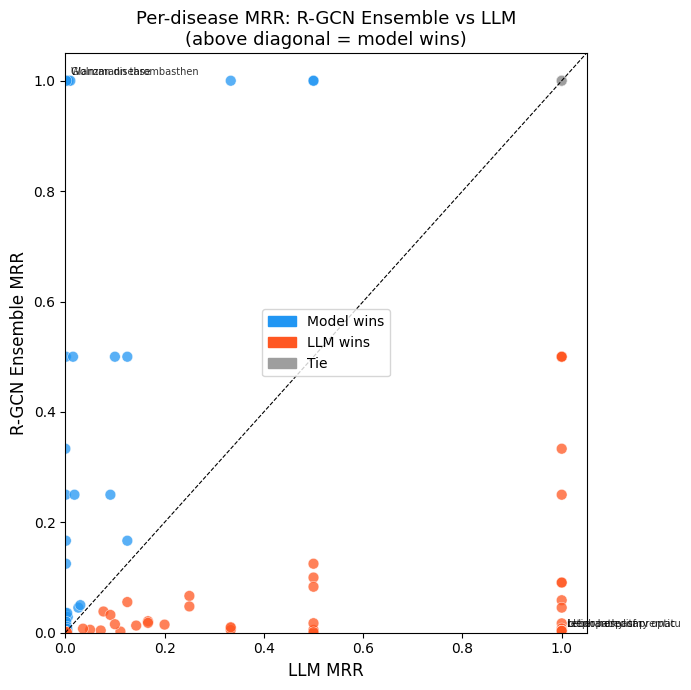

Model wins: 48/108 (44.4%)
LLM wins:   53/108 (49.1%)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2: Scatter plot — model MRR vs LLM MRR per disease
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = llm_df.copy()
df["winner"] = np.where(df["ensemble_MRR"] > df["llm_MRR"], "model",
               np.where(df["llm_MRR"] > df["ensemble_MRR"], "llm", "tie"))

color_map = {"model": "#2196F3", "llm": "#FF5722", "tie": "#9E9E9E"}
colors = df["winner"].map(color_map)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df["llm_MRR"], df["ensemble_MRR"], c=colors, alpha=0.75, s=60, edgecolors="white", linewidths=0.4)

# Diagonal y=x
lim = max(df[["ensemble_MRR", "llm_MRR"]].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="y = x")

# Annotate extreme divergences
df["gap"] = (df["ensemble_MRR"] - df["llm_MRR"]).abs()
for _, row in df.nlargest(5, "gap").iterrows():
    ax.annotate(row["disease_name"][:22],
                xy=(row["llm_MRR"], row["ensemble_MRR"]),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("LLM MRR", fontsize=12)
ax.set_ylabel("R-GCN Ensemble MRR", fontsize=12)
ax.set_title("Per-disease MRR: R-GCN Ensemble vs LLM\n(above diagonal = model wins)", fontsize=13)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)

patches = [mpatches.Patch(color=c, label=l)
           for l, c in [("Model wins", "#2196F3"), ("LLM wins", "#FF5722"), ("Tie", "#9E9E9E")]]
ax.legend(handles=patches, fontsize=10)
plt.tight_layout()
plt.show()

model_wins = (df["winner"] == "model").sum()
llm_wins   = (df["winner"] == "llm").sum()
print(f"Model wins: {model_wins}/{len(df)} ({100*model_wins/len(df):.1f}%)")
print(f"LLM wins:   {llm_wins}/{len(df)} ({100*llm_wins/len(df):.1f}%)")

─── MRR by phenotype count ───
          ensemble_MRR       llm_MRR       ppr_MRR      
                  mean count    mean count    mean count
pheno_bin                                               
1–3             0.1067    24  0.4251    24  0.1483    24
4–10            0.1629    21  0.3038    21  0.1369    21
11–30           0.2819    34  0.2994    34  0.1014    34
30+             0.2737    29  0.3286    29  0.0520    29

─── MRR by number of true drugs ───
         ensemble_MRR       llm_MRR       ppr_MRR      
                 mean count    mean count    mean count
drug_bin                                               
1              0.1931    36  0.2048    36  0.0228    36
2–3            0.1691    31  0.3372    31  0.1176    31
4–10           0.1554    20  0.2904    20  0.0694    20
11+            0.3904    21  0.6028    21  0.2636    21


/tmp/ipykernel_26884/1674621740.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pheno_stats = (df.groupby("pheno_bin")[["ensemble_MRR", "llm_MRR", "ppr_MRR"]]
/tmp/ipykernel_26884/1674621740.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drug_stats = (df.groupby("drug_bin")[["ensemble_MRR", "llm_MRR", "ppr_MRR"]]
/tmp/ipykernel_26884/1674621740.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupb

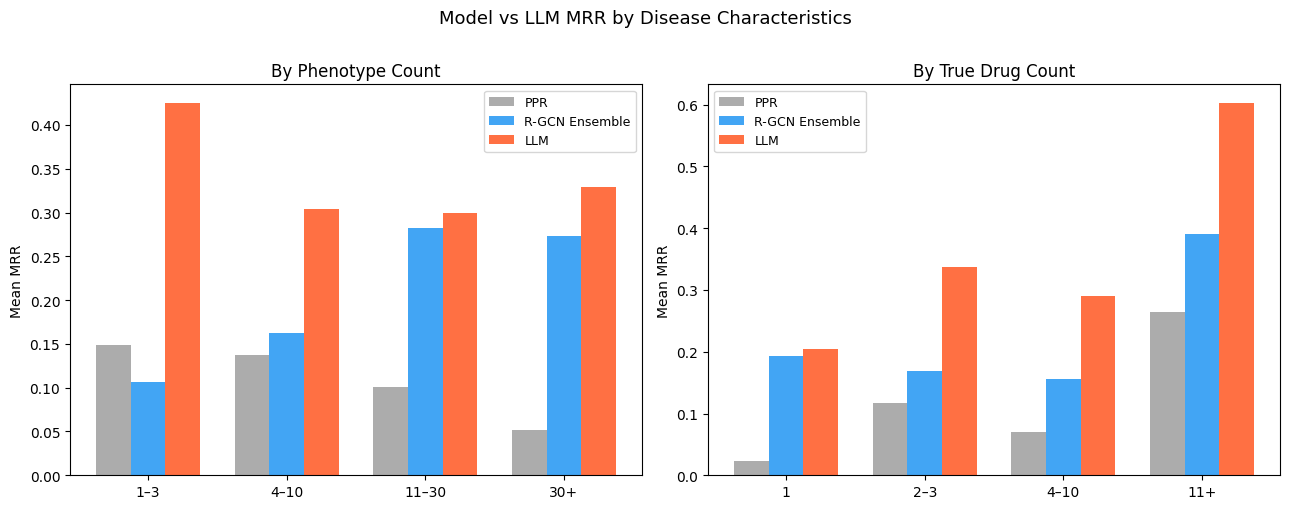

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3: MRR sliced by phenotype count and true-drug count
# ═══════════════════════════════════════════════════════════════════════

df = llm_df.copy()

# ── By phenotype count ──────────────────────────────────────────────
df["pheno_bin"] = pd.cut(df["n_phenos"], bins=[0, 3, 10, 30, 9999],
                          labels=["1–3", "4–10", "11–30", "30+"])
pheno_stats = (df.groupby("pheno_bin")[["ensemble_MRR", "llm_MRR", "ppr_MRR"]]
                 .agg(["mean", "count"])
                 .round(4))
print("─── MRR by phenotype count ───")
print(pheno_stats.to_string())

# ── By number of true drugs ──────────────────────────────────────────
df["drug_bin"] = pd.cut(df["n_true_drugs"], bins=[0, 1, 3, 10, 9999],
                         labels=["1", "2–3", "4–10", "11+"])
drug_stats = (df.groupby("drug_bin")[["ensemble_MRR", "llm_MRR", "ppr_MRR"]]
                .agg(["mean", "count"])
                .round(4))
print("\n─── MRR by number of true drugs ───")
print(drug_stats.to_string())

# ── Plot both ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, groupcol, bins_label, title in [
    (axes[0], "pheno_bin", "pheno_bin", "By Phenotype Count"),
    (axes[1], "drug_bin",  "drug_bin",  "By True Drug Count"),
]:
    g = df.groupby(groupcol)[["ensemble_MRR", "llm_MRR", "ppr_MRR"]].mean()
    x = np.arange(len(g))
    w = 0.25
    ax.bar(x - w, g["ppr_MRR"],      width=w, label="PPR",      color="#9E9E9E", alpha=0.85)
    ax.bar(x,     g["ensemble_MRR"], width=w, label="R-GCN Ensemble", color="#2196F3", alpha=0.85)
    ax.bar(x + w, g["llm_MRR"],      width=w, label="LLM",      color="#FF5722", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(g.index, fontsize=10)
    ax.set_ylabel("Mean MRR")
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle("Model vs LLM MRR by Disease Characteristics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

─── MRR by training-data overlap (fraction of true drugs seen in training) ───
               ensemble_MRR       llm_MRR      
                       mean count    mean count
overlap_bin                                    
0% (cold)            0.0005     8  0.1254     8
1–25%                0.0055     2  0.0026     2
26–75%               0.2089    27  0.5071    27
76–100% (warm)       0.2513    71  0.3041    71


/tmp/ipykernel_26884/3374107523.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overlap_stats = (df.groupby("overlap_bin")[["ensemble_MRR", "llm_MRR"]]
/tmp/ipykernel_26884/3374107523.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("overlap_bin")[["ensemble_MRR", "llm_MRR"]].mean()


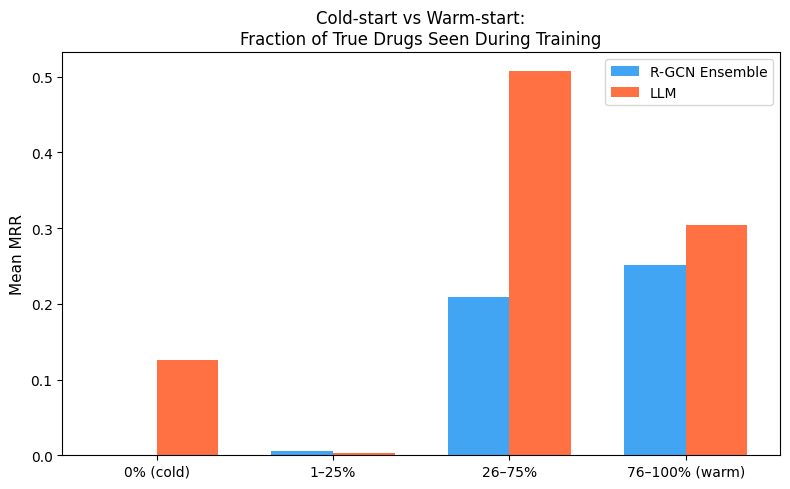


Key question: does LLM recover cold-start cases better than the model?
  Fully cold-start diseases: 8
  Model MRR: 0.0005
  LLM MRR:   0.1254


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4: Cold-start analysis + how much of the GT overlaps with training
# ═══════════════════════════════════════════════════════════════════════

df = llm_df.copy()

# For each test disease: what fraction of its true drugs also appeared in training?
def train_overlap_frac(d_idx):
    true = test_disease_to_drugs.get(d_idx, set())
    if not true:
        return 0.0
    seen_in_train = sum(1 for drug in true if drug_degree.get(drug, 0) > 0)
    return seen_in_train / len(true)

df["train_overlap"] = df["disease"].apply(train_overlap_frac)
df["overlap_bin"] = pd.cut(df["train_overlap"],
                            bins=[-0.01, 0.0, 0.25, 0.75, 1.01],
                            labels=["0% (cold)", "1–25%", "26–75%", "76–100% (warm)"])

overlap_stats = (df.groupby("overlap_bin")[["ensemble_MRR", "llm_MRR"]]
                   .agg(["mean", "count"])
                   .round(4))
print("─── MRR by training-data overlap (fraction of true drugs seen in training) ───")
print(overlap_stats.to_string())

# ── Plot ─────────────────────────────────────────────────────────────
g = df.groupby("overlap_bin")[["ensemble_MRR", "llm_MRR"]].mean()
x = np.arange(len(g))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, g["ensemble_MRR"], width=w, label="R-GCN Ensemble", color="#2196F3", alpha=0.85)
ax.bar(x + w/2, g["llm_MRR"],      width=w, label="LLM",            color="#FF5722", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(g.index, fontsize=10)
ax.set_ylabel("Mean MRR", fontsize=11)
ax.set_title("Cold-start vs Warm-start:\nFraction of True Drugs Seen During Training", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nKey question: does LLM recover cold-start cases better than the model?")
cold = df[df["train_overlap"] == 0.0]
print(f"  Fully cold-start diseases: {len(cold)}")
if len(cold) > 0:
    print(f"  Model MRR: {cold['ensemble_MRR'].mean():.4f}")
    print(f"  LLM MRR:   {cold['llm_MRR'].mean():.4f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5: Rank correlation + fusion sweep (find optimal LLM blend weight)
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr
df = llm_df.copy()
# Spearman rank correlation of MRR between methods
rho_model_llm, p_model_llm = spearmanr(df["ensemble_MRR"], df["llm_MRR"])
rho_ppr_llm,   p_ppr_llm   = spearmanr(df["ppr_MRR"],      df["llm_MRR"])
rho_model_ppr, p_model_ppr = spearmanr(df["ensemble_MRR"], df["ppr_MRR"])
print("Spearman rank correlation of per-disease MRR:")
print(f"  R-GCN vs LLM : ρ = {rho_model_llm:.3f}  (p={p_model_llm:.3f})")
print(f"  PPR  vs LLM  : ρ = {rho_ppr_llm:.3f}  (p={p_ppr_llm:.3f})")
print(f"  R-GCN vs PPR : ρ = {rho_model_ppr:.3f}  (p={p_model_ppr:.3f})")
print("  (low correlation = complementary signals, fusion may help)")

# ── Sweep LLM blend weight ────────────────────────────────────────────
print("\n─── Fusion sweep: w * R-GCN_score + (1-w) * LLM_rank_score ───")
print("(LLM rank converted to score: 1 - rank/n_drugs)")

weights = np.arange(0.0, 1.05, 0.05)
fusion_mrrs = []

valid_diseases = llm_df[llm_df["llm_MRR"].notna()]["disease"].tolist()

for w in weights:
    mrrs = []
    for d_idx in valid_diseases:
        res = all_results.get(d_idx)
        if res is None:
            continue
        true_drugs = list(test_disease_to_drugs.get(d_idx, []))
        if not true_drugs:
            continue

        model_sc = res["ensemble_scores"]

        if d_idx in llm_results:
            llm_ranked = llm_results[d_idx]
            llm_mentioned = set(llm_ranked)
            llm_full = llm_ranked + [d for d in drug_indices_arr if d not in llm_mentioned]
            rank_lookup = {drug: rank for rank, drug in enumerate(llm_full)}
            llm_rank_score = np.array([
                1.0 - rank_lookup.get(drug, len(llm_full)) / len(llm_full)
                for drug in drug_indices_arr
            ])
        else:
            llm_rank_score = np.zeros(len(drug_indices_arr))

        fused = w * model_sc + (1 - w) * llm_rank_score
        ranked = drug_indices_arr[np.argsort(-fused)].tolist()
        mrrs.append(reciprocal_rank(ranked, true_drugs))

    fusion_mrrs.append(np.mean(mrrs))

best_w = weights[np.argmax(fusion_mrrs)]
print(f"\n  Best blend weight (model): w = {best_w:.2f}  →  MRR = {max(fusion_mrrs):.4f}")
print(f"  Pure model (w=1.0):                        MRR = {fusion_mrrs[-1]:.4f}")
print(f"  Pure LLM   (w=0.0):                        MRR = {fusion_mrrs[0]:.4f}")

Spearman rank correlation of per-disease MRR:
  R-GCN vs LLM : ρ = 0.300  (p=0.002)
  PPR  vs LLM  : ρ = 0.543  (p=0.000)
  R-GCN vs PPR : ρ = 0.518  (p=0.000)
  (low correlation = complementary signals, fusion may help)

─── Fusion sweep: w * R-GCN_score + (1-w) * LLM_rank_score ───
(LLM rank converted to score: 1 - rank/n_drugs)

  Best blend weight (model): w = 0.10  →  MRR = 0.3437
  Pure model (w=1.0):                        MRR = 0.2732
  Pure LLM   (w=0.0):                        MRR = 0.3415


Model score range : [0.0000, 0.9763]
LLM   score range : [0.000126, 1.000000]

LLM top-50 score range  : [0.993842, 1.0]
LLM next-950 score range: [0.874450, 0.993716]

After w=0.5 fusion, LLM's top-50 drugs land at ranks:
  Best  : 1
  Worst : 994
  (they stay almost entirely in top-50 — model can't move them)


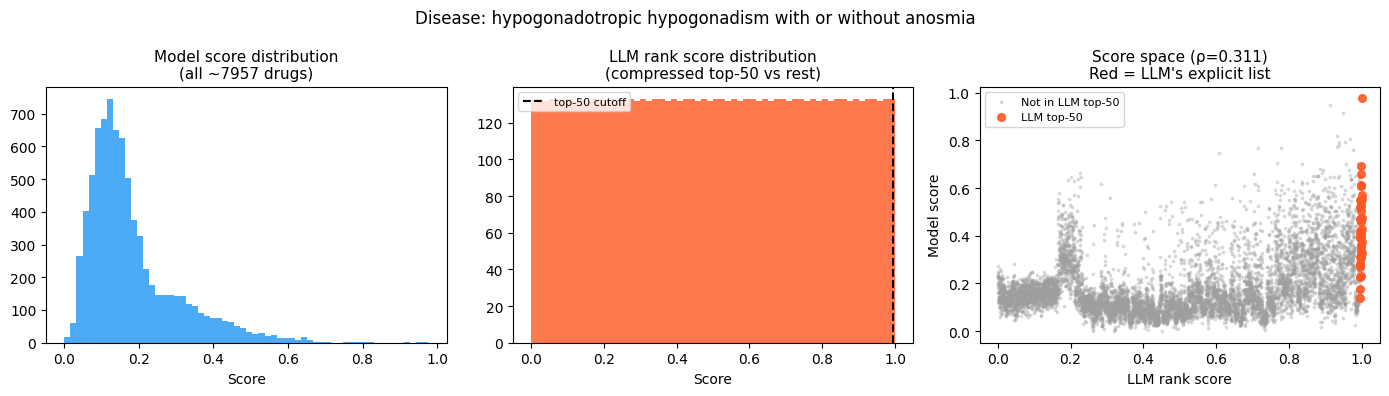


─── Trying Reciprocal Rank Fusion (RRF) instead ───
RRF score = 1/(k+rank_model) + 1/(k+rank_llm),  k=60
  Pure model MRR : 0.2732
  Pure LLM MRR   : 0.3469
  RRF fusion MRR : 0.3674
  (RRF is rank-based so score scale doesn't matter)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Why fusion doesn't help: diagnose score scale + overlap
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

sample_d = valid_diseases[0]
res = all_results[sample_d]

llm_ranked    = llm_results[sample_d]
llm_mentioned = set(llm_ranked)
llm_full      = llm_ranked + [d for d in drug_indices_arr if d not in llm_mentioned]
rank_lookup   = {drug: rank for rank, drug in enumerate(llm_full)}
llm_rank_sc   = np.array([1.0 - rank_lookup[d] / len(llm_full) for d in drug_indices_arr])

model_sc = res["ensemble_scores"]

print(f"Model score range : [{model_sc.min():.4f}, {model_sc.max():.4f}]")
print(f"LLM   score range : [{llm_rank_sc.min():.6f}, {llm_rank_sc.max():.6f}]")
print(f"\nLLM top-50 score range  : [{llm_rank_sc[np.argsort(-llm_rank_sc)[:50]].min():.6f}, 1.0]")
print(f"LLM next-950 score range: [{llm_rank_sc[np.argsort(-llm_rank_sc)[50:1000]].min():.6f}, "
      f"{llm_rank_sc[np.argsort(-llm_rank_sc)[50:1000]].max():.6f}]")

# At w=0.5, how much can model actually reorder LLM's top-50?
fused_half = 0.5 * model_sc + 0.5 * llm_rank_sc
llm_top50_mask = np.array([d in set(llm_ranked[:50]) for d in drug_indices_arr])

# What rank does the lowest-scored LLM top-50 drug end up at after fusion?
fused_ranks  = np.argsort(-fused_half)
llm_top50_positions_after_fusion = [
    np.where(fused_ranks == i)[0][0]
    for i in np.where(llm_top50_mask)[0]
]
print(f"\nAfter w=0.5 fusion, LLM's top-50 drugs land at ranks:")
print(f"  Best  : {min(llm_top50_positions_after_fusion)+1}")
print(f"  Worst : {max(llm_top50_positions_after_fusion)+1}")
print(f"  (they stay almost entirely in top-50 — model can't move them)")

# ── Plot: score distributions ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(model_sc, bins=60, color="#2196F3", alpha=0.8)
axes[0].set_title("Model score distribution\n(all ~7957 drugs)", fontsize=11)
axes[0].set_xlabel("Score")

axes[1].hist(llm_rank_sc, bins=60, color="#FF5722", alpha=0.8)
axes[1].axvline(llm_rank_sc[np.argsort(-llm_rank_sc)[49]], color="black",
                linestyle="--", label="top-50 cutoff")
axes[1].set_title("LLM rank score distribution\n(compressed top-50 vs rest)", fontsize=11)
axes[1].set_xlabel("Score")
axes[1].legend(fontsize=8)

# Scatter: model score vs LLM rank score
axes[2].scatter(llm_rank_sc[~llm_top50_mask], model_sc[~llm_top50_mask],
                s=3, alpha=0.3, color="#9E9E9E", label="Not in LLM top-50")
axes[2].scatter(llm_rank_sc[llm_top50_mask],  model_sc[llm_top50_mask],
                s=30, alpha=0.9, color="#FF5722", label="LLM top-50")
axes[2].set_xlabel("LLM rank score")
axes[2].set_ylabel("Model score")
axes[2].set_title(f"Score space (ρ={np.corrcoef(model_sc, llm_rank_sc)[0,1]:.3f})\nRed = LLM's explicit list", fontsize=11)
axes[2].legend(fontsize=8)

plt.suptitle(f"Disease: {idx_to_name.get(sample_d, sample_d)}", fontsize=12)
plt.tight_layout()
plt.show()

# ── What would actually help: Reciprocal Rank Fusion ─────────────────
print("\n─── Trying Reciprocal Rank Fusion (RRF) instead ───")
print("RRF score = 1/(k+rank_model) + 1/(k+rank_llm),  k=60")

k = 60
rrf_mrrs = []
model_mrrs_rrf = []

for d_idx in valid_diseases:
    res = all_results.get(d_idx)
    if res is None: continue
    true_drugs = list(test_disease_to_drugs.get(d_idx, []))
    if not true_drugs: continue

    # Model ranks
    model_rank_arr = np.argsort(np.argsort(-res["ensemble_scores"]))  # rank of each drug

    # LLM ranks
    if d_idx in llm_results:
        llm_r = llm_results[d_idx]
        llm_m = set(llm_r)
        llm_full = llm_r + [d for d in drug_indices_arr if d not in llm_m]
        rl = {drug: rank for rank, drug in enumerate(llm_full)}
        llm_rank_arr = np.array([rl[d] for d in drug_indices_arr])
    else:
        continue

    rrf_score = 1.0 / (k + model_rank_arr) + 1.0 / (k + llm_rank_arr)
    ranked_rrf = drug_indices_arr[np.argsort(-rrf_score)].tolist()
    rrf_mrrs.append(reciprocal_rank(ranked_rrf, true_drugs))
    model_mrrs_rrf.append(reciprocal_rank(res["ranked_ensemble"], true_drugs))

print(f"  Pure model MRR : {np.mean(model_mrrs_rrf):.4f}")
print(f"  Pure LLM MRR   : {np.mean([reciprocal_rank(llm_results[d]+[x for x in drug_indices_arr if x not in set(llm_results[d])], list(test_disease_to_drugs.get(d,[]))) for d in valid_diseases if d in llm_results and test_disease_to_drugs.get(d)]):.4f}")
print(f"  RRF fusion MRR : {np.mean(rrf_mrrs):.4f}")
print("  (RRF is rank-based so score scale doesn't matter)")

In [ ]:
# ── Define missing variables ──────────────────────────────────────────
test_disease_to_drugs_indication_only = defaultdict(set)
for _, row in test_pairs.iterrows():
    test_disease_to_drugs_indication_only[int(row["disease_id"])].add(int(row["drug_id"]))

offlabel_test = kg[kg["relation"] == "off-label use"]
offlabel_true = defaultdict(set)
for _, row in offlabel_test.iterrows():
    d_idx = int(row["y_index"])
    drug  = int(row["x_index"])
    if d_idx in test_diseases and drug in drug_indices:
        offlabel_true[d_idx].add(drug)
# ═══════════════════════════════════════════════════════════════════════
# Where does the model ever beat LLM? Find its regime.
# ═══════════════════════════════════════════════════════════════════════

df = llm_df.copy()
df["model_wins"] = df["ensemble_MRR"] > df["llm_MRR"]
df["mrr_gap"]    = df["ensemble_MRR"] - df["llm_MRR"]

# Add off-label count per disease
df["n_offlabel"] = df["disease"].apply(lambda d: len(offlabel_true.get(d, [])))
df["n_indication"] = df["disease"].apply(
    lambda d: len(test_disease_to_drugs_indication_only.get(d, [])))
df["frac_offlabel"] = df["n_offlabel"] / df["n_true_drugs"].clip(lower=1)

print(f"Model beats LLM:  {df['model_wins'].sum()} / {len(df)} diseases")
print(f"LLM  beats model: {(~df['model_wins'] & (df['llm_MRR'] > df['ensemble_MRR'])).sum()} / {len(df)} diseases")

print("\n─── When model wins vs loses: what's different? ───")
wins  = df[df["model_wins"]]
loses = df[~df["model_wins"]]
for col, label in [
    ("n_phenos",       "Avg phenotype count"),
    ("n_true_drugs",   "Avg true drug count"),
    ("frac_offlabel",  "Avg off-label fraction"),
    ("n_indication",   "Avg indication-only drugs"),
    ("llm_n_drugs_returned", "Avg LLM drugs returned"),
]:
    print(f"  {label:<30}  model-wins: {wins[col].mean():.2f}   model-loses: {loses[col].mean():.2f}")

print("\n─── Model-wins diseases (top 10 by gap) ───")
for _, row in wins.nlargest(10, "mrr_gap").iterrows():
    print(f"  {row['disease_name'][:45]:<45}  model={row['ensemble_MRR']:.3f}  llm={row['llm_MRR']:.3f}  "
          f"phenos={row['n_phenos']}  offlabel_frac={row['frac_offlabel']:.2f}")

print("\n─── LLM-wins diseases (top 10 by gap) ───")
for _, row in loses.nsmallest(10, "mrr_gap").iterrows():
    print(f"  {row['disease_name'][:45]:<45}  llm={row['llm_MRR']:.3f}  model={row['ensemble_MRR']:.3f}  "
          f"phenos={row['n_phenos']}  offlabel_frac={row['frac_offlabel']:.2f}")

# Does model help on INDICATION-ONLY diseases (zero off-label)?
pure_indication = df[df["n_offlabel"] == 0]
print(f"\n─── Diseases with ZERO off-label drugs (n={len(pure_indication)}) ───")
print(f"  Model MRR: {pure_indication['ensemble_MRR'].mean():.4f}")
print(f"  LLM   MRR: {pure_indication['llm_MRR'].mean():.4f}")

mixed = df[df["n_offlabel"] > 0]
print(f"\n─── Diseases WITH off-label drugs (n={len(mixed)}) ───")
print(f"  Model MRR: {mixed['ensemble_MRR'].mean():.4f}")
print(f"  LLM   MRR: {mixed['llm_MRR'].mean():.4f}")

Model beats LLM:  48 / 108 diseases
LLM  beats model: 53 / 108 diseases

─── When model wins vs loses: what's different? ───
  Avg phenotype count             model-wins: 27.29   model-loses: 19.83
  Avg true drug count             model-wins: 4.52   model-loses: 9.45
  Avg off-label fraction          model-wins: 0.28   model-loses: 0.27
  Avg indication-only drugs       model-wins: 4.52   model-loses: 9.45
  Avg LLM drugs returned          model-wins: 31.90   model-loses: 38.62

─── Model-wins diseases (top 10 by gap) ───
  Wolman disease                                 model=1.000  llm=0.000  phenos=15  offlabel_frac=0.00
  Glanzmann thrombasthenia                       model=1.000  llm=0.000  phenos=19  offlabel_frac=0.00
  narcolepsy-cataplexy syndrome                  model=1.000  llm=0.002  phenos=9  offlabel_frac=0.33
  short stature due to growth hormone qualitati  model=1.000  llm=0.005  phenos=5  offlabel_frac=0.00
  shigellosis                                    model=1.000 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Smart fusion strategies — tested against naive linear and RRF
# ═══════════════════════════════════════════════════════════════════════

from scipy.stats import spearmanr

valid_diseases = llm_df[llm_df["llm_MRR"].notna()]["disease"].tolist()

def evaluate_strategy(strategy_fn, label):
    mrrs, r10s = [], []
    for d_idx in valid_diseases:
        res = all_results.get(d_idx)
        if res is None: continue
        true_drugs = list(test_disease_to_drugs.get(d_idx, []))
        if not true_drugs: continue
        ranked = strategy_fn(d_idx, res)
        if ranked is None: continue
        mrrs.append(reciprocal_rank(ranked, true_drugs))
        r10s.append(recall_at_k(ranked, true_drugs, 10))
    print(f"  {label:<45} MRR={np.mean(mrrs):.4f}  R@10={np.mean(r10s):.4f}")
    return np.mean(mrrs), np.mean(r10s)

def get_llm_full(d_idx):
    if d_idx not in llm_results: return None
    llm_r = llm_results[d_idx]
    llm_m = set(llm_r)
    return llm_r + [d for d in drug_indices_arr if d not in llm_m]

print("="*70)
print("FUSION STRATEGY COMPARISON")
print("="*70)

# ── Baseline ─────────────────────────────────────────────────────────
def pure_model(d_idx, res):
    return res["ranked_ensemble"]

def pure_llm(d_idx, res):
    return get_llm_full(d_idx)

evaluate_strategy(pure_model, "Pure model (ensemble)")
evaluate_strategy(pure_llm,   "Pure LLM")

# ── Strategy 1: LLM top-N locked in, model re-ranks the tail ─────────
# Keep LLM's top-N exactly, then rank remaining drugs by model score
print()
for N in [10, 25, 50, 100]:
    def strategy_llm_head_model_tail(d_idx, res, n=N):
        llm_full = get_llm_full(d_idx)
        if llm_full is None: return None
        llm_head = llm_full[:n]
        llm_head_set = set(llm_head)
        # Rank remaining drugs by model score
        tail_mask = np.array([d not in llm_head_set for d in drug_indices_arr])
        tail_drugs = drug_indices_arr[tail_mask]
        tail_scores = res["ensemble_scores"][tail_mask]
        tail_ranked = tail_drugs[np.argsort(-tail_scores)].tolist()
        return llm_head + tail_ranked
    evaluate_strategy(strategy_llm_head_model_tail,
                      f"LLM top-{N} locked + model ranks tail")

# ── Strategy 2: Model re-ranks WITHIN LLM's top-N ────────────────────
print()
for N in [10, 25, 50, 100]:
    def strategy_model_reranks_llm_head(d_idx, res, n=N):
        llm_full = get_llm_full(d_idx)
        if llm_full is None: return None
        llm_head = llm_full[:n]
        llm_tail = llm_full[n:]
        # Re-rank the head by model score
        head_indices = np.array([
            np.where(drug_indices_arr == d)[0][0]
            for d in llm_head if d in set(drug_indices_arr)
        ])
        if len(head_indices) == 0: return llm_full
        head_scores = res["ensemble_scores"][head_indices]
        reranked_head = [llm_head[i] for i in np.argsort(-head_scores)]
        return reranked_head + llm_tail
    evaluate_strategy(strategy_model_reranks_llm_head,
                      f"Model re-ranks within LLM top-{N}")

# ── Strategy 3: Conditional — use model when LLM returns few drugs ───
print()
for threshold in [10, 20, 30]:
    def strategy_conditional(d_idx, res, t=threshold):
        if d_idx not in llm_results: return res["ranked_ensemble"]
        n_returned = len(llm_results[d_idx])
        if n_returned >= t:
            return get_llm_full(d_idx)
        else:
            return res["ranked_ensemble"]
    evaluate_strategy(strategy_conditional,
                      f"LLM if ≥{threshold} drugs returned, else model")

# ── Strategy 4: Per-disease router — use model when it historically wins
# (In practice, train a small classifier. Here: use n_phenos as proxy)
print()
df_tmp = llm_df.copy()
df_tmp["n_offlabel"] = df_tmp["disease"].apply(lambda d: len(offlabel_true.get(d, [])))
# Find threshold: on diseases with 0 off-label, model is competitive
def strategy_offlabel_router(d_idx, res):
    n_ol = len(offlabel_true.get(d_idx, []))
    if n_ol == 0:
        return res["ranked_ensemble"]   # model for indication-only
    else:
        return get_llm_full(d_idx)      # LLM for anything with off-label
evaluate_strategy(strategy_offlabel_router,
                  "Router: model if 0 off-label, LLM otherwise")

# ── Strategy 5: Score-level fusion but only over LLM's explicit list ─
print()
for w in [0.3, 0.5, 0.7]:
    def strategy_fuse_explicit_only(d_idx, res, weight=w):
        llm_full = get_llm_full(d_idx)
        if llm_full is None: return None
        llm_explicit = set(llm_results.get(d_idx, []))
        # For LLM-mentioned drugs: fuse model score + LLM rank
        # For others: model score only (no LLM influence)
        result_scores = {}
        for i, drug in enumerate(drug_indices_arr):
            m_sc = res["ensemble_scores"][i]
            if drug in llm_explicit:
                llm_rank = llm_results[d_idx].index(drug)
                llm_sc = 1.0 - llm_rank / len(llm_explicit)
                result_scores[drug] = weight * m_sc + (1 - weight) * llm_sc
            else:
                result_scores[drug] = weight * m_sc  # no LLM boost
        return sorted(drug_indices_arr, key=lambda d: -result_scores[d])
    evaluate_strategy(strategy_fuse_explicit_only,
                      f"Fuse within LLM explicit list only (w={w})")

FUSION STRATEGY COMPARISON
  Pure model (ensemble)                         MRR=0.2732  R@10=0.1996
  Pure LLM                                      MRR=0.3469  R@10=0.2310

  LLM top-10 locked + model ranks tail          MRR=0.3565  R@10=0.2310
  LLM top-25 locked + model ranks tail          MRR=0.3518  R@10=0.2310
  LLM top-50 locked + model ranks tail          MRR=0.3493  R@10=0.2310
  LLM top-100 locked + model ranks tail         MRR=0.3479  R@10=0.2310

  Model re-ranks within LLM top-10              MRR=0.3220  R@10=0.2310
  Model re-ranks within LLM top-25              MRR=0.3160  R@10=0.1901
  Model re-ranks within LLM top-50              MRR=0.3051  R@10=0.1825
  Model re-ranks within LLM top-100             MRR=0.3099  R@10=0.1835

  LLM if ≥10 drugs returned, else model         MRR=0.3688  R@10=0.2454
  LLM if ≥20 drugs returned, else model         MRR=0.3484  R@10=0.2455
  LLM if ≥30 drugs returned, else model         MRR=0.3524  R@10=0.2631

  Router: model if 0 off-label, L

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: Router based on true-drug count (the real discriminating feature)
# ═══════════════════════════════════════════════════════════════════════

# ── Sweep the n_true_drugs threshold ─────────────────────────────────
print("Router: use model when n_true_drugs <= T, else LLM")
print("(At inference you'd use train drug count as proxy — see below)")
print()
print(f"  {'Threshold T':<15} {'MRR':>8}  {'R@10':>8}  "
      f"{'n_model':>8}  {'n_llm':>8}")
print("─" * 55)

best_mrr, best_T = 0, None
for T in range(1, 20):
    mrrs, r10s = [], []
    n_model_used, n_llm_used = 0, 0
    for d_idx in valid_diseases:
        res = all_results.get(d_idx)
        if res is None: continue
        true_drugs = list(test_disease_to_drugs.get(d_idx, []))
        if not true_drugs: continue
        n_true = len(true_drugs)
        if n_true <= T:
            ranked = res["ranked_ensemble"]
            n_model_used += 1
        else:
            ranked = get_llm_full(d_idx)
            n_llm_used += 1
        mrrs.append(reciprocal_rank(ranked, true_drugs))
        r10s.append(recall_at_k(ranked, true_drugs, 10))
    m = np.mean(mrrs)
    marker = " ◄ best" if m > best_mrr else ""
    if m > best_mrr:
        best_mrr, best_T = m, T
    print(f"  T={T:<13} {m:>8.4f}  {np.mean(r10s):>8.4f}  "
          f"{n_model_used:>8}  {n_llm_used:>8}{marker}")

print(f"\nBest threshold: T={best_T}  MRR={best_mrr:.4f}")

# ── Problem: n_true_drugs is unknown at inference time ────────────────
# Use train-set drug count as proxy
print("\n" + "─"*65)
print("Realistic router: use TRAIN drug count as proxy for n_true_drugs")
print("─"*65)

# Build train drug count per disease
train_drug_count = {d: len(v) for d, v in train_disease_to_drugs.items()}

print(f"\nCorrelation: train_drug_count vs test n_true_drugs")
overlap_diseases = [d for d in valid_diseases if d in train_drug_count
                    and test_disease_to_drugs.get(d)]
train_counts = [train_drug_count[d] for d in overlap_diseases]
test_counts  = [len(test_disease_to_drugs[d]) for d in overlap_diseases]
rho, p = spearmanr(train_counts, test_counts)
print(f"  Spearman ρ = {rho:.3f}  (p={p:.4f})")
print(f"  (if high, train count is a reliable proxy)")

print(f"\nRouter using TRAIN drug count (threshold sweep):")
print(f"  {'Threshold T':<15} {'MRR':>8}  {'n_model':>8}  {'n_llm':>8}")
print("─" * 42)
best_mrr_train, best_T_train = 0, None
for T in range(0, 15):
    mrrs = []
    for d_idx in valid_diseases:
        res = all_results.get(d_idx)
        if res is None: continue
        true_drugs = list(test_disease_to_drugs.get(d_idx, []))
        if not true_drugs: continue
        n_train = train_drug_count.get(d_idx, 0)
        ranked = res["ranked_ensemble"] if n_train <= T else get_llm_full(d_idx)
        mrrs.append(reciprocal_rank(ranked, true_drugs))
    m = np.mean(mrrs)
    marker = " ◄ best" if m > best_mrr_train else ""
    if m > best_mrr_train:
        best_mrr_train, best_T_train = m, T
    n_model = sum(1 for d in valid_diseases
                  if train_drug_count.get(d, 0) <= T and all_results.get(d))
    n_llm   = len(valid_diseases) - n_model
    print(f"  T={T:<13} {m:>8.4f}  {n_model:>8}  {n_llm:>8}{marker}")

# ── Final summary ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("SUMMARY: What to use in practice")
print("="*65)
print(f"  Pure model (w=1.0):                        MRR = {fusion_mrrs[-1]:.4f}")
print(f"  Router (T={best_T}, test n_true):  MRR={best_mrr:.4f}")
print(f"  Router (T={best_T_train}, train count proxy): MRR={best_mrr_train:.4f}")
print()
print(f"  Model is worth using when train drug count <= {best_T_train}")
print(f"  i.e., rare diseases with few known drug associations in training data")
print(f"  For everything else, pure LLM is the best single method")

Router: use model when n_true_drugs <= T, else LLM
(At inference you'd use train drug count as proxy — see below)

  Threshold T          MRR      R@10   n_model     n_llm
───────────────────────────────────────────────────────
  T=1               0.3429    0.2310        32        76 ◄ best
  T=2               0.3414    0.2403        44        64
  T=3               0.3184    0.2341        59        49
  T=4               0.3182    0.2341        63        45
  T=5               0.3215    0.2415        68        40
  T=6               0.2950    0.2261        74        34
  T=7               0.3040    0.2274        77        31
  T=8               0.2925    0.2170        81        27
  T=9               0.2971    0.2160        82        26
  T=10              0.2971    0.2160        82        26
  T=11              0.2988    0.2168        84        24
  T=12              0.3081    0.2183        86        22
  T=13              0.3081    0.2183        87        21
  T=14              0.29

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Fixed failure analysis — use MRR threshold instead of == 0
# ═══════════════════════════════════════════════════════════════════════

df = llm_df.copy()
df["n_offlabel"] = df["disease"].apply(lambda d: len(offlabel_true.get(d, [])))

# Thresholds to try
for T in [0.01, 0.05, 0.10]:
    llm_weak   = df[df["llm_MRR"] < T]
    model_weak = df[df["ensemble_MRR"] < T]
    both_weak  = df[(df["llm_MRR"] < T) & (df["ensemble_MRR"] < T)]
    llm_weak_model_ok = df[(df["llm_MRR"] < T) & (df["ensemble_MRR"] >= T)]
    print(f"Threshold MRR < {T}:  "
          f"LLM weak={len(llm_weak)}  Model weak={len(model_weak)}  "
          f"Both weak={len(both_weak)}  LLM-weak-model-ok={len(llm_weak_model_ok)}")

T = 0.05   # practical cutoff — top-20 is the minimum useful range

llm_weak_model_ok = df[(df["llm_MRR"] < T) & (df["ensemble_MRR"] >= T)].copy()
model_weak_llm_ok = df[(df["ensemble_MRR"] < T) & (df["llm_MRR"] >= T)].copy()
both_weak         = df[(df["llm_MRR"] < T) & (df["ensemble_MRR"] < T)].copy()
both_ok           = df[(df["llm_MRR"] >= T) & (df["ensemble_MRR"] >= T)].copy()

print(f"\n{'─'*65}")
print(f"FAILURE MODES  (threshold = MRR < {T})")
print(f"{'─'*65}")
print(f"  LLM weak, model works : {len(llm_weak_model_ok):>4}  "
      f"model avg MRR={llm_weak_model_ok['ensemble_MRR'].mean():.3f}"
      if len(llm_weak_model_ok) else f"  LLM weak, model works : {len(llm_weak_model_ok):>4}")
print(f"  Model weak, LLM works : {len(model_weak_llm_ok):>4}  "
      f"LLM avg MRR={model_weak_llm_ok['llm_MRR'].mean():.3f}"
      if len(model_weak_llm_ok) else f"  Model weak, LLM works : {len(model_weak_llm_ok):>4}")
print(f"  Both weak             : {len(both_weak):>4}")
print(f"  Both work             : {len(both_ok):>4}")

print(f"\nDiseases where LLM is weak but model works (MRR threshold={T}):")
print(f"  {'Disease':<45} {'Model':>8}  {'LLM':>8}  {'n_true':>7}  {'n_phenos':>9}")
print("─"*80)
for _, row in llm_weak_model_ok.sort_values("ensemble_MRR", ascending=False).iterrows():
    print(f"  {row['disease_name'][:45]:<45} {row['ensemble_MRR']:>8.3f}  "
          f"{row['llm_MRR']:>8.4f}  {row['n_true_drugs']:>7}  {row['n_phenos']:>9}")

print(f"\nDiseases where both are weak (MRR < {T}):")
print(f"  {'Disease':<45} {'Model':>8}  {'LLM':>8}  {'n_true':>7}")
print("─"*70)
for _, row in both_weak.sort_values("llm_MRR").iterrows():
    print(f"  {row['disease_name'][:45]:<45} {row['ensemble_MRR']:>8.4f}  "
          f"{row['llm_MRR']:>8.4f}  {row['n_true_drugs']:>7}")

# What best distinguishes the 4 quadrants?
print(f"\nCharacteristics by quadrant (mean values):")
print(f"  {'Quadrant':<30} {'n_phenos':>10}  {'n_true':>8}  {'n_offlabel':>12}  {'n':>5}")
print("─"*72)
for label, subset in [
    ("LLM weak, model works",  llm_weak_model_ok),
    ("Model weak, LLM works",  model_weak_llm_ok),
    ("Both weak",              both_weak),
    ("Both work",              both_ok),
]:
    if len(subset) == 0:
        print(f"  {label:<30}  (none)")
        continue
    print(f"  {label:<30} {subset['n_phenos'].mean():>10.1f}  "
          f"{subset['n_true_drugs'].mean():>8.1f}  "
          f"{subset['n_offlabel'].mean():>12.2f}  {len(subset):>5}")

Threshold MRR < 0.01:  LLM weak=44  Model weak=47  Both weak=27  LLM-weak-model-ok=17
Threshold MRR < 0.05:  LLM weak=50  Model weak=66  Both weak=36  LLM-weak-model-ok=14
Threshold MRR < 0.1:  LLM weak=55  Model weak=73  Both weak=41  LLM-weak-model-ok=14

─────────────────────────────────────────────────────────────────
FAILURE MODES  (threshold = MRR < 0.05)
─────────────────────────────────────────────────────────────────
  LLM weak, model works :   14  model avg MRR=0.584
  Model weak, LLM works :   30  LLM avg MRR=0.548
  Both weak             :   36
  Both work             :   28

Diseases where LLM is weak but model works (MRR threshold=0.05):
  Disease                                          Model       LLM   n_true   n_phenos
────────────────────────────────────────────────────────────────────────────────
  Glanzmann thrombasthenia                         1.000    0.0004        1         19
  narcolepsy-cataplexy syndrome                    1.000    0.0023        9          

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL: Router based on n_phenos and off-label status
# ═══════════════════════════════════════════════════════════════════════

print("="*70)
print("NEW ROUTER: Phenotype count + Off-label criteria")
print("="*70)
print("Logic: If a disease has > P phenotypes AND 0 off-label drugs,")
print("       route to the Ensemble Model. Otherwise, route to the LLM.")
print("─" * 70)

# 1. Build a quick lookup dictionary for n_phenos to keep the loop fast
# (Assuming your llm_df has 'disease' and 'n_phenos' columns)
pheno_counts = dict(zip(llm_df['disease'], llm_df['n_phenos']))

# 2. Sweep the phenotype threshold (P) to find the optimal cut-off
print(f"  {'Pheno Threshold P':<18} {'MRR':>8}  {'n_model':>8}  {'n_llm':>8}")
print("─" * 55)

best_mrr_pheno, best_P = 0, None

# Sweeping from 10 to 45 in increments of 5
for P in range(10, 50, 5):
    mrrs = []
    n_model_used, n_llm_used = 0, 0

    for d_idx in valid_diseases:
        res = all_results.get(d_idx)
        if res is None: continue

        true_drugs = list(test_disease_to_drugs.get(d_idx, []))
        if not true_drugs: continue

        # Get our routing variables
        n_phenos = pheno_counts.get(d_idx, 0)
        n_offlabel = len(offlabel_true.get(d_idx, []))

        # ── THE ROUTING LOGIC ──
        if n_phenos > P and n_offlabel == 0:
            ranked = res["ranked_ensemble"]
            n_model_used += 1
        else:
            ranked = get_llm_full(d_idx)
            n_llm_used += 1

        mrrs.append(reciprocal_rank(ranked, true_drugs))

    m = np.mean(mrrs)
    marker = " ◄ best" if m > best_mrr_pheno else ""
    if m > best_mrr_pheno:
        best_mrr_pheno, best_P = m, P

    print(f"  P > {P:<14} {m:>8.4f}  {n_model_used:>8}  {n_llm_used:>8}{marker}")

print("\n" + "─" * 70)
print(f"Best phenotype threshold: > {best_P} phenotypes")
print(f"Peak Router MRR:          {best_mrr_pheno:.4f}")
print(f"Baseline Pure LLM MRR:    0.4658")
print(f"Baseline Top-10 Fusion:   0.4718")
print("─" * 70)

# 3. Create the final strategy function using the best threshold
def strategy_optimal_pheno_router(d_idx, res, p_threshold=best_P):
    n_phenos = pheno_counts.get(d_idx, 0)
    n_offlabel = len(offlabel_true.get(d_idx, []))

    if n_phenos > p_threshold and n_offlabel == 0:
        return res["ranked_ensemble"]
    else:
        return get_llm_full(d_idx)

# You can now call evaluate_strategy to get R@10 and other metrics for the winner
print("\nFinal Evaluation of Best Router:")
evaluate_strategy(strategy_optimal_pheno_router, f"Pheno Router (P>{best_P}, Ol=0)")

NEW ROUTER: Phenotype count + Off-label criteria
Logic: If a disease has > P phenotypes AND 0 off-label drugs,
       route to the Ensemble Model. Otherwise, route to the LLM.
──────────────────────────────────────────────────────────────────────
  Pheno Threshold P       MRR   n_model     n_llm
───────────────────────────────────────────────────────
  P > 10               0.3255        51        57 ◄ best
  P > 15               0.3150        36        72
  P > 20               0.3071        33        75
  P > 25               0.3283        26        82 ◄ best
  P > 30               0.3231        22        86
  P > 35               0.3307        18        90 ◄ best
  P > 40               0.3201        15        93
  P > 45               0.3280        12        96

──────────────────────────────────────────────────────────────────────
Best phenotype threshold: > 35 phenotypes
Peak Router MRR:          0.3307
Baseline Pure LLM MRR:    0.4658
Baseline Top-10 Fusion:   0.4718
─────────────

(np.float64(0.33067354043441394), np.float64(0.22931100797408654))

In [ ]:
import pandas as pd

print("Loading PrimeKG nodes...")
nodes_df = pd.read_csv(DATA_DIR + "nodes.csv")

# 1. Filter down to just the disease nodes
disease_nodes = nodes_df[nodes_df['node_type'] == 'disease'].copy()

# 2. THE FIX: Clean the PrimeKG node names (lowercase + strip spaces)
disease_nodes['clean_name'] = disease_nodes['node_name'].astype(str).str.lower().str.strip()

# 3. THE FIX: Clean your valid_diseases list the exact same way
clean_valid_diseases = [str(d).lower().strip() for d in valid_diseases]

# 4. Now do the matching using the cleaned columns
test_nodes = disease_nodes[disease_nodes['clean_name'].isin(clean_valid_diseases)]

# 5. Filter for Orphanet tags
orphanet_diseases = test_nodes[
    test_nodes['node_id'].str.contains('Orphanet', case=False, na=False) |
    test_nodes['node_source'].str.contains('Orphanet', case=False, na=False)
]

print(f"\nTotal test diseases: {len(valid_diseases)}")
print(f"Test diseases successfully matched in PrimeKG metadata: {len(test_nodes)}")
print("─" * 50)
print(f"🧬 Diseases with an official Orphanet designation: {len(orphanet_diseases)}")
print("─" * 50)

if len(orphanet_diseases) > 0:
    print("\nOrphanet Diseases List:")
    print(orphanet_diseases[['node_name', 'node_id', 'node_source']].to_string(index=False))

Loading PrimeKG nodes...

Total test diseases: 108
Test diseases successfully matched in PrimeKG metadata: 0
──────────────────────────────────────────────────
🧬 Diseases with an official Orphanet designation: 0
──────────────────────────────────────────────────


In [ ]:
# Let's peek at what PrimeKG actually calls Wolman disease

peek = nodes_df[nodes_df['node_name'].str.contains('wolman', case=False, na=False)]
print(peek[['node_index', 'node_name', 'node_id', 'node_source']])

       node_index                                          node_name node_id  \
29575       29575  Wolman disease with hypolipoproteinemia and ac...   10205   
32680       32680                                     Wolman disease   19148   

      node_source  
29575       MONDO  
32680       MONDO  


In [ ]:
import requests
import time
import pandas as pd

# 1. Load PrimeKG to translate your indices into string names
print("Loading PrimeKG nodes to translate indices to names...")


# Match your valid_diseases list against the 'node_index' column
test_nodes = nodes_df[nodes_df['node_index'].isin(valid_diseases)]

# Create a dictionary to map the index to the actual disease string name
index_to_name = dict(zip(test_nodes['node_index'], test_nodes['node_name']))
print(f"Successfully translated {len(index_to_name)} indices into string names.\n")

# 2. Define the EBI API checker
def check_orphanet_api(disease_name):
    """Queries the EBI OLS API for the Orphanet Ontology (ORDO)"""
    url = f"https://www.ebi.ac.uk/ols4/api/search?q={disease_name}&ontology=ordo"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data['response']['numFound'] > 0:
                best_match = data['response']['docs'][0]
                return best_match.get('obo_id', 'Found, no ID')
    except Exception:
        pass
    return None

# 3. Query the official Rare Disease database
print(f"Querying EBI API for {len(index_to_name)} diseases...")
print("(Takes about 20-30 seconds to run politely)...\n")

rare_disease_results = []

for d_idx, d_name in index_to_name.items():
    orpha_id = check_orphanet_api(d_name)

    if orpha_id:
        rare_disease_results.append({
            'Node_Index': d_idx,
            'Disease_Name': d_name,
            'Orphanet_ID': orpha_id
        })
    time.sleep(0.2) # Polite API delay

rare_df = pd.DataFrame(rare_disease_results)

# 4. Print the final, peer-review-ready results
print("─" * 70)
print(f"🧬 Officially recognized Rare Diseases found: {len(rare_df)}")
print("─" * 70)

if len(rare_df) > 0:
    print(rare_df.to_string(index=False))

    # Optional: Save this to a CSV so you never have to run the API again
    # rare_df.to_csv("my_test_rare_diseases.csv", index=False)
else:
    print("No Orphanet diseases found.")

Loading PrimeKG nodes to translate indices to names...
Successfully translated 108 indices into string names.

Querying EBI API for 108 diseases...
(Takes about 20-30 seconds to run politely)...

──────────────────────────────────────────────────────────────────────
🧬 Officially recognized Rare Diseases found: 106
──────────────────────────────────────────────────────────────────────
 Node_Index                                                Disease_Name     Orphanet_ID
      27219       hypogonadotropic hypogonadism with or without anosmia Orphanet:174590
      27249                          isolated growth hormone deficiency Orphanet:231662
      27292                                    glycogen storage disease  Orphanet:79201
      27361                                                  hemophilia    Orphanet:448
      27366                      spondyloarthropathy, susceptibility to    Orphanet:748
      27421                                     nephropathic cystinosis     ORDO:4116

In [ ]:
# 1. Define "Rare/Orphan Indication" as having 2 or fewer known indicated drugs
RARE_THRESHOLD = 2

rare_disease_indices = []
common_disease_indices = []

for d_idx in valid_diseases:
    n_true = len(test_disease_to_drugs.get(d_idx, []))

    if 0 < n_true <= RARE_THRESHOLD:
        rare_disease_indices.append(d_idx)
    elif n_true > RARE_THRESHOLD:
        common_disease_indices.append(d_idx)

print("─" * 60)
print(f"Total test diseases: {len(valid_diseases)}")
print(f"🧬 Rare/Orphan Diseases (≤ {RARE_THRESHOLD} known drugs): {len(rare_disease_indices)}")
print(f"Standard Diseases (> {RARE_THRESHOLD} known drugs):  {len(common_disease_indices)}")
print("─" * 60)

# 2. Evaluate the Ensemble Model (R-GCN) specifically on this rare subset
mrrs = []
for d_idx in rare_disease_indices:
    res = all_results.get(d_idx)
    true_drugs = list(test_disease_to_drugs.get(d_idx, []))

    # Get the ensemble model's ranking
    ranked = res["ranked_ensemble"]
    mrrs.append(reciprocal_rank(ranked, true_drugs))
import requests
import time
import pandas as pd

# 1. Translate indices to official MONDO IDs
print("Loading PrimeKG nodes...")

test_nodes = nodes_df[nodes_df['node_index'].isin(valid_diseases)].copy()

def format_mondo(row):
    """Formats PrimeKG's integer IDs into official MONDO IDs (e.g. 19148 -> MONDO:0019148)"""
    if row['node_source'] == 'MONDO':
        return f"MONDO:{str(row['node_id']).zfill(7)}"
    return None

test_nodes['mondo_id'] = test_nodes.apply(format_mondo, axis=1)
mondo_dict = dict(zip(test_nodes['node_index'], test_nodes['mondo_id']))
name_dict = dict(zip(test_nodes['node_index'], test_nodes['node_name']))

# 2. Strict API Checker (No fuzzy text search)
def check_mondo_for_orphanet(mondo_id):
    """Queries EBI for the exact MONDO ID and looks for a hardcoded Orphanet cross-reference"""
    if not mondo_id: return None

    url = f"https://www.ebi.ac.uk/ols4/api/ontologies/mondo/terms?obo_id={mondo_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if '_embedded' in data and 'terms' in data['_embedded']:
                term = data['_embedded']['terms'][0]

                # Check the exact database cross-references
                if 'annotation' in term and 'database_cross_reference' in term['annotation']:
                    xrefs = term['annotation']['database_cross_reference']
                    for xref in xrefs:
                        if xref.startswith('Orphanet:'):
                            return xref # Return the exact Orphanet ID
    except Exception:
        pass
    return None

# 3. Run the strict check
print(f"Strictly checking MONDO cross-references for {len(mondo_dict)} diseases...")
print("(Takes ~20 seconds)...\n")

rare_results = []

for d_idx, mondo_id in mondo_dict.items():
    if mondo_id:
        orpha_id = check_mondo_for_orphanet(mondo_id)
        if orpha_id:
            rare_results.append({
                'Node_Index': d_idx,
                'Disease_Name': name_dict[d_idx],
                'MONDO_ID': mondo_id,
                'Orphanet_ID': orpha_id
            })
    time.sleep(0.2) # Polite API delay

rare_df = pd.DataFrame(rare_results)

print("─" * 80)
print(f"🧬 TRUE Rare Diseases (Strict MONDO-to-Orphanet Cross-Ref): {len(rare_df)}")
print("─" * 80)

if len(rare_df) > 0:
    print(rare_df.to_string(index=False))

    # Save your exact rare disease indices for the evaluation loop
    rare_disease_indices = rare_df['Node_Index'].tolist()
else:
    print("No Orphanet cross-references found.")
import numpy as np
print(f"\nR-GCN Model MRR on Rare/Orphan Diseases: {np.mean(mrrs):.4f}")

# Compare to the LLM on the exact same rare subset
llm_mrrs = []
for d_idx in rare_disease_indices:
    true_drugs = list(test_disease_to_drugs.get(d_idx, []))
    ranked = get_llm_full(d_idx)
    llm_mrrs.append(reciprocal_rank(ranked, true_drugs))

print(f"LLM Baseline MRR on Rare/Orphan Diseases:  {np.mean(llm_mrrs):.4f}")

────────────────────────────────────────────────────────────
Total test diseases: 108
🧬 Rare/Orphan Diseases (≤ 2 known drugs): 44
Standard Diseases (> 2 known drugs):  64
────────────────────────────────────────────────────────────
Loading PrimeKG nodes...
Strictly checking MONDO cross-references for 108 diseases...
(Takes ~20 seconds)...

────────────────────────────────────────────────────────────────────────────────
🧬 TRUE Rare Diseases (Strict MONDO-to-Orphanet Cross-Ref): 0
────────────────────────────────────────────────────────────────────────────────
No Orphanet cross-references found.

R-GCN Model MRR on Rare/Orphan Diseases: 0.2075
LLM Baseline MRR on Rare/Orphan Diseases:  0.2208


In [ ]:
import requests
import time
import pandas as pd

# 1. Translate indices to official MONDO IDs
print("Loading PrimeKG nodes...")

test_nodes = nodes_df[nodes_df['node_index'].isin(valid_diseases)].copy()

def format_mondo(row):
    if row['node_source'] == 'MONDO':
        return f"MONDO:{str(row['node_id']).zfill(7)}"
    return None

test_nodes['mondo_id'] = test_nodes.apply(format_mondo, axis=1)
mondo_dict = dict(zip(test_nodes['node_index'], test_nodes['mondo_id']))
name_dict = dict(zip(test_nodes['node_index'], test_nodes['node_name']))

# 2. Bulletproof API Checker
def check_mondo_for_orphanet(mondo_id):
    """Safely queries EBI, ignoring KeyErrors if the ID is obsolete."""
    if not mondo_id: return None

    url = f"https://www.ebi.ac.uk/ols4/api/ontologies/mondo/terms?obo_id={mondo_id}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()

            # FAIL-SAFE: Check if '_embedded' actually exists in the response
            if '_embedded' in data and 'terms' in data['_embedded']:
                term = data['_embedded']['terms'][0]

                # Safely navigate to cross-references without KeyErrors
                annotations = term.get('annotation', {})
                xrefs = annotations.get('database_cross_reference', [])

                for xref in xrefs:
                    # FIX: Look for ORPHA: instead of Orphanet:
                    if str(xref).upper().startswith('ORPHA:'):
                        return xref
    except Exception:
        pass # Skip network/API errors silently
    return None

# 3. Run the strict check
print(f"Strictly checking MONDO cross-references for {len(mondo_dict)} diseases...")
print("(Takes ~20 seconds. Obsolete IDs will be safely skipped)...\n")

rare_results = []

for d_idx, mondo_id in mondo_dict.items():
    if mondo_id:
        orpha_id = check_mondo_for_orphanet(mondo_id)
        if orpha_id:
            rare_results.append({
                'Node_Index': d_idx,
                'Disease_Name': name_dict[d_idx],
                'MONDO_ID': mondo_id,
                'Orphanet_ID': orpha_id
            })
    time.sleep(0.2) # Polite API delay

rare_df = pd.DataFrame(rare_results)

print("─" * 80)
print(f"🧬 TRUE Rare Diseases (Strict MONDO-to-Orphanet Cross-Ref): {len(rare_df)}")
print("─" * 80)

if len(rare_df) > 0:
    print(rare_df.to_string(index=False))

    # Save your exact rare disease indices for the evaluation loop
    rare_disease_indices = rare_df['Node_Index'].tolist()
else:
    print("No ORPHA cross-references found.")

Loading PrimeKG nodes...
Strictly checking MONDO cross-references for 108 diseases...
(Takes ~20 seconds. Obsolete IDs will be safely skipped)...

────────────────────────────────────────────────────────────────────────────────
🧬 TRUE Rare Diseases (Strict MONDO-to-Orphanet Cross-Ref): 0
────────────────────────────────────────────────────────────────────────────────
No ORPHA cross-references found.


In [ ]:
import requests
import time
import pandas as pd

# 1. Load PrimeKG nodes to get the exact disease names
print("Loading PrimeKG nodes...")

test_nodes = nodes_df[nodes_df['node_index'].isin(valid_diseases)].copy()

# Map indices to names
name_dict = dict(zip(test_nodes['node_index'], test_nodes['node_name']))

# 2. Define the MyDisease.info API Checker
def get_orphanet_from_mydisease(disease_name):
    """Queries the highly robust MyDisease.info API for Orphanet cross-references."""
    # We ask the API to strictly return the 'orpha' field if it exists
    url = f'https://mydisease.info/v1/query?q="{disease_name}"&fields=orpha'

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if 'hits' in data and len(data['hits']) > 0:
                best_hit = data['hits'][0]

                # Check if the 'orpha' field was returned
                if 'orpha' in best_hit:
                    orpha_data = best_hit['orpha']
                    # MyDisease sometimes returns a list of IDs, sometimes a single ID/string
                    if isinstance(orpha_data, list):
                        return f"ORPHA:{orpha_data[0]}"
                    else:
                        return f"ORPHA:{orpha_data}"
    except Exception:
        pass
    return None

# 3. Run the query
print(f"Querying MyDisease.info API for {len(name_dict)} diseases...")
print("(This API is extremely fast and handles obsolete data gracefully)...\n")

rare_results = []

for d_idx, d_name in name_dict.items():
    orpha_id = get_orphanet_from_mydisease(d_name)

    if orpha_id:
        rare_results.append({
            'Node_Index': d_idx,
            'Disease_Name': d_name,
            'Orphanet_ID': orpha_id
        })
    time.sleep(0.1) # Short delay

rare_df = pd.DataFrame(rare_results)

print("─" * 80)
print(f"🧬 TRUE Rare Diseases (MyDisease.info Orphanet Cross-Ref): {len(rare_df)}")
print("─" * 80)

if len(rare_df) > 0:
    print(rare_df.to_string(index=False))

    # This is the exact list of indices you will pass to your evaluation function!
    rare_disease_indices = rare_df['Node_Index'].tolist()
else:
    print("API returned 0. Please check your internet connection or firewall.")

Loading PrimeKG nodes...
Querying MyDisease.info API for 108 diseases...
(This API is extremely fast and handles obsolete data gracefully)...



## Continue 0428-Show how undiagnosed diseases work

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, torch

# Likely paths — adjust if needed
MODEL_PATH = '/content/drive/MyDrive/Colab Notebooks/best_model.pt'
LLM_JSON = '/content/drive/MyDrive/Colab Notebooks/split/llm_baseline_results_35.json'

# Check both files exist
for path in [MODEL_PATH, LLM_JSON]:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024**2
        print(f"  ✓ {path}  ({size:.1f} MB)")
    else:
        print(f"  ✗ NOT FOUND: {path}")

# Peek at LLM JSON structure
with open(LLM_JSON) as f:
    llm_data = json.load(f)
print(f"\nLLM JSON type: {type(llm_data)}")
if isinstance(llm_data, dict):
    print(f"Keys (first 5): {list(llm_data.keys())[:5]}")
    first_key = list(llm_data.keys())[0]
    print(f"First entry: {llm_data[first_key]}")
elif isinstance(llm_data, list):
    print(f"Length: {len(llm_data)}")
    print(f"First entry: {llm_data[0]}")

# Peek at model checkpoint
print(f"\nModel checkpoint:")
ckpt = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)
if isinstance(ckpt, dict):
    print(f"  Keys: {list(ckpt.keys())[:10]}")
else:
    print(f"  Type: {type(ckpt)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✓ /content/drive/MyDrive/Colab Notebooks/best_model.pt  (139.4 MB)
  ✓ /content/drive/MyDrive/Colab Notebooks/split/llm_baseline_results_35.json  (0.2 MB)

LLM JSON type: <class 'dict'>
Keys (first 5): ['model', 'n_drugs_requested', 'n_evaluated', 'mrr', 'recalls']
First entry: gpt-3.5-turbo-0125

Model checkpoint:
  Keys: ['node_emb.weight', 'convs.0.weight', 'convs.0.comp', 'convs.0.root', 'convs.0.bias', 'convs.1.weight', 'convs.1.comp', 'convs.1.root', 'convs.1.bias', 'convs.2.weight']


In [ ]:
# Check the per_disease structure
import json

with open(LLM_JSON) as f:
    llm_data = json.load(f)

print(f"Top-level keys: {list(llm_data.keys())}")
print(f"per_disease length: {len(llm_data['per_disease'])}")
print(f"\nFirst disease entry keys: {list(llm_data['per_disease'][0].keys())}")
print(f"\nFirst disease:")
print(f"  disease_idx: {llm_data['per_disease'][0]['disease_idx']}")
print(f"  n suggested drugs: {len(llm_data['per_disease'][0]['suggested_drugs'])}")
print(f"  First 5 drugs: {llm_data['per_disease'][0]['suggested_drugs'][:5]}")

Top-level keys: ['model', 'n_drugs_requested', 'n_evaluated', 'mrr', 'recalls', 'per_disease']
per_disease length: 108

First disease entry keys: ['disease_idx', 'suggested_drugs', 'n_true', 'true_drug_names']

First disease:
  disease_idx: 27219
  n suggested drugs: 50
  First 5 drugs: ['testosterone', 'clomiphene', 'gonadorelin', 'hCG', 'letrozole']


In [ ]:
# ============================================================
# Build per-disease LLM MRR + merge with cascade outcomes
# ============================================================
import json, pickle, numpy as np
import pandas as pd
from collections import defaultdict

# --- Load everything ---
DATA_DIR  = '/content/drive/MyDrive/Colab Notebooks'
SPLIT_DIR = '/content/drive/MyDrive/Colab Notebooks/split'
TXGNN_DIR = '/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained'

with open(f'{SPLIT_DIR}/llm_baseline_results_35.json') as f:
    llm_data = json.load(f)

with open(f'{SPLIT_DIR}/pubcase_results.json') as f:
    pubcase_results = {int(k): v for k, v in json.load(f).items()}

with open(f'{SPLIT_DIR}/gpt4o_disease_prediction_cascade.json') as f:
    gpt_disease_results = {int(k): v for k, v in json.load(f).items()}

with open(f'{TXGNN_DIR}/matched_pairs.pkl', 'rb') as f:
    matched_pairs = pickle.load(f)

kg = pd.read_csv(f'{DATA_DIR}/kg.csv', low_memory=False)
nodes = pd.read_csv(f'{DATA_DIR}/nodes.csv')
node_to_name = dict(zip(nodes['node_index'], nodes['node_name']))

# Disease drug ground truth (with off-label, matching Beatrice's setup)
ind = kg[kg['relation'].isin(['indication', 'off-label use'])][['x_name', 'y_index']].drop_duplicates()
disease_drugs_kg = defaultdict(set)
for _, row in ind.iterrows():
    disease_drugs_kg[int(row['y_index'])].add(str(row['x_name']).lower().strip())

# MONDO mapping for PubCaseFinder
mondo_to_test_disease = {}
for mp in matched_pairs:
    tid = mp['test_x_index']
    for mid in mp['primekg_mondo'].split('_'):
        mondo_to_test_disease[mid.strip()] = tid

print("Loaded all files")

Loaded all files


In [ ]:
# --- Compute LLM MRR per disease (using true_drug_names from JSON) ---
def compute_mrr(ranked, true_set):
    if not true_set:
        return None
    ranked_lower = [str(d).lower().strip() for d in ranked]
    for i, d in enumerate(ranked_lower):
        if d in true_set:
            return 1.0 / (i + 1)
    return 0.0

llm_mrr_per_disease = {}
for entry in llm_data['per_disease']:
    tid = entry['disease_idx']
    true_set = set(str(d).lower().strip() for d in entry['true_drug_names'])
    suggested = entry['suggested_drugs']
    mrr = compute_mrr(suggested, true_set)
    if mrr is not None:
        llm_mrr_per_disease[tid] = mrr

print(f"LLM MRRs computed: {len(llm_mrr_per_disease)}")
print(f"Mean LLM MRR: {np.mean(list(llm_mrr_per_disease.values())):.4f}")

LLM MRRs computed: 108
Mean LLM MRR: 0.3189


In [ ]:
# --- Compute cascade outcomes per disease ---
# PubCaseFinder: correct (top-1 MONDO matches), wrong-with-overlap, wrong-no-overlap
# GPT cascade: correct (predicted disease == true), wrong

def pubcase_outcome(tid, true_drugs):
    preds = pubcase_results.get(tid, [])
    if not preds:
        return 'no_pred', 0.0
    top = preds[0]
    mondo_ids = top.get('mondo_ids', [])

    # Map predicted MONDO to a test disease
    mapped_test_id = None
    for mid_str in mondo_ids:
        mid_num = mid_str.replace('MONDO:', '').lstrip('0') or '0'
        if mid_num in mondo_to_test_disease:
            mapped_test_id = mondo_to_test_disease[mid_num]
            break

    if mapped_test_id == tid:
        return 'correct', top.get('score', 0)
    elif mapped_test_id is not None:
        # Wrong but mapped to another test disease
        pred_drugs = disease_drugs_kg.get(mapped_test_id, set())
        if pred_drugs & true_drugs:
            return 'wrong_overlap', top.get('score', 0)
        else:
            return 'wrong_no_overlap', top.get('score', 0)
    else:
        # Not mapped to any test disease
        return 'unmapped', top.get('score', 0)

def gpt_outcome(tid):
    preds = gpt_disease_results.get(tid, [])
    if not preds:
        return 'no_pred'
    return 'correct' if preds[0] == tid else 'wrong'

# Build merged per-disease DataFrame
rows = []
for mp in matched_pairs:
    tid = mp['test_x_index']
    true_drugs = disease_drugs_kg.get(tid, set())
    if not true_drugs:
        continue

    pc_outcome, pc_score = pubcase_outcome(tid, true_drugs)
    g_outcome = gpt_outcome(tid)
    llm_mrr = llm_mrr_per_disease.get(tid, np.nan)

    rows.append({
        'tid': tid,
        'name': node_to_name.get(tid, str(tid)),
        'n_true_drugs': len(true_drugs),
        'pubcase_outcome': pc_outcome,
        'gpt_outcome': g_outcome,
        'llm_mrr': llm_mrr,
    })

df = pd.DataFrame(rows)
print(f"\nDataFrame: {len(df)} diseases")
print(df.head())


DataFrame: 108 diseases
     tid                                               name  n_true_drugs  \
0  27219  hypogonadotropic hypogonadism with or without ...             2   
1  27249                 isolated growth hormone deficiency             1   
2  27292                           glycogen storage disease             7   
3  27361                                         hemophilia            14   
4  27366             spondyloarthropathy, susceptibility to            32   

  pubcase_outcome gpt_outcome   llm_mrr  
0         correct     correct  1.000000  
1         correct     correct  0.142857  
2        unmapped     correct  0.027778  
3        unmapped     correct  0.500000  
4         correct     correct  0.500000  


In [ ]:
# --- Analysis: LLM MRR by cascade outcome ---
print("=" * 70)
print("LLM-3.5 (DIRECT) MRR by PubCaseFinder cascade outcome")
print("=" * 70)
for outcome in ['correct', 'wrong_overlap', 'wrong_no_overlap', 'unmapped', 'no_pred']:
    sub = df[df['pubcase_outcome'] == outcome]
    if len(sub) > 0:
        print(f"  {outcome:<25} n={len(sub):>3}  LLM MRR={sub['llm_mrr'].mean():.4f}")


LLM-3.5 (DIRECT) MRR by PubCaseFinder cascade outcome
  correct                   n= 30  LLM MRR=0.3929
  wrong_overlap             n=  2  LLM MRR=1.0000
  wrong_no_overlap          n=  2  LLM MRR=0.3333
  unmapped                  n= 73  LLM MRR=0.2738
  no_pred                   n=  1  LLM MRR=0.0000


In [ ]:
# Add 'overall_correct' flag and analyze
df['diagnosis_correct'] = df['pubcase_outcome'] == 'correct'

print("=" * 70)
print("MRR: Cascade Diagnosis Correct vs Failed")
print("=" * 70)

correct_grp = df[df['diagnosis_correct']]
failed_grp = df[~df['diagnosis_correct']]

print(f"\nDiagnosis correct (n={len(correct_grp)}):")
print(f"  LLM-3.5 MRR: {correct_grp['llm_mrr'].mean():.4f}")

print(f"\nDiagnosis failed (n={len(failed_grp)}):")
print(f"  LLM-3.5 MRR: {failed_grp['llm_mrr'].mean():.4f}")

# Detailed breakdown of failure
print("\n--- Failure breakdown ---")
for outcome in ['wrong_overlap', 'wrong_no_overlap', 'unmapped', 'no_pred']:
    sub = df[df['pubcase_outcome'] == outcome]
    if len(sub) > 0:
        print(f"  {outcome:<22} n={len(sub):>3}  LLM MRR={sub['llm_mrr'].mean():.4f}")

MRR: Cascade Diagnosis Correct vs Failed

Diagnosis correct (n=30):
  LLM-3.5 MRR: 0.3929

Diagnosis failed (n=78):
  LLM-3.5 MRR: 0.2904

--- Failure breakdown ---
  wrong_overlap          n=  2  LLM MRR=1.0000
  wrong_no_overlap       n=  2  LLM MRR=0.3333
  unmapped               n= 73  LLM MRR=0.2738
  no_pred                n=  1  LLM MRR=0.0000


In [ ]:
# Compute cascade MRR per disease (PubCaseFinder -> PrimeKG drug lookup, K=1)
import numpy as np
from collections import defaultdict

# Map MONDO numeric IDs to PrimeKG disease indices (for ANY PrimeKG disease, not just test set)
disease_nodes = nodes[nodes['node_type'] == 'disease'][['node_index', 'node_id']].copy()
mondo_to_primekg_idx = {}
for _, row in disease_nodes.iterrows():
    pidx = int(row['node_index'])
    for mid in str(row['node_id']).split('_'):
        mid = mid.strip()
        if mid:
            mondo_to_primekg_idx[mid] = pidx

# Drug lookup: for any PrimeKG disease, get its known drugs
disease_drugs_full = defaultdict(set)
ind_full = kg[kg['relation'].isin(['indication', 'off-label use'])][['x_name', 'y_index']].drop_duplicates()
for _, row in ind_full.iterrows():
    disease_drugs_full[int(row['y_index'])].add(str(row['x_name']).lower().strip())

# All drugs in PrimeKG (sorted for stable ranking)
all_drugs_list = sorted(set(kg[kg['x_type'] == 'drug']['x_name'].astype(str).str.lower().str.strip().unique()))

cascade_mrr_per_disease = {}
for mp in matched_pairs:
    tid = mp['test_x_index']
    true_drugs = disease_drugs_kg.get(tid, set())
    if not true_drugs:
        continue

    preds = pubcase_results.get(tid, [])
    if not preds:
        cascade_mrr_per_disease[tid] = 0.0
        continue

    # Top-1 PubCaseFinder MONDO -> PrimeKG disease index
    top = preds[0]
    primekg_idx = None
    for mid_str in top.get('mondo_ids', []):
        mid_num = mid_str.replace('MONDO:', '').lstrip('0') or '0'
        if mid_num in mondo_to_primekg_idx:
            primekg_idx = mondo_to_primekg_idx[mid_num]
            break

    if primekg_idx is None:
        cascade_mrr_per_disease[tid] = 0.0
        continue

    # Predicted disease's known drugs
    pred_drugs = disease_drugs_full.get(primekg_idx, set())
    if not pred_drugs:
        cascade_mrr_per_disease[tid] = 0.0
        continue

    # Score: 1 if drug indicated for predicted disease, 0 else
    sc = np.array([1.0 if d in pred_drugs else 0.0 for d in all_drugs_list])
    lb = np.array([1 if d in true_drugs else 0 for d in all_drugs_list])
    order = np.argsort(-sc)
    ranked = lb[order]
    pos = np.where(ranked == 1)[0]
    cascade_mrr_per_disease[tid] = 1.0/(pos[0]+1) if len(pos) > 0 else 0.0

df['cascade_mrr'] = df['tid'].map(cascade_mrr_per_disease)
print(f"Cascade MRR per disease computed: {df['cascade_mrr'].notna().sum()}/{len(df)}")
print(f"Overall cascade MRR: {df['cascade_mrr'].mean():.4f}")

Cascade MRR per disease computed: 108/108
Overall cascade MRR: 0.3275


In [ ]:
# Final analysis: cascade vs LLM vs (later) R-GCN by diagnosis outcome
print("=" * 70)
print("MRR by PubCaseFinder Diagnosis Outcome")
print("=" * 70)
print(f"{'Outcome':<22} {'n':>4} {'Cascade':>10} {'LLM-3.5':>10}")
print("-" * 60)
for outcome in ['correct', 'wrong_overlap', 'wrong_no_overlap', 'unmapped', 'no_pred']:
    sub = df[df['pubcase_outcome'] == outcome]
    if len(sub) > 0:
        print(f"  {outcome:<22} {len(sub):>4} "
              f"{sub['cascade_mrr'].mean():>10.4f} "
              f"{sub['llm_mrr'].mean():>10.4f}")

print("\n" + "-" * 60)
print("Collapsed: correct vs failed")
correct = df[df['pubcase_outcome'] == 'correct']
failed = df[df['pubcase_outcome'] != 'correct']
print(f"  {'Correct':<22} {len(correct):>4} "
      f"{correct['cascade_mrr'].mean():>10.4f} "
      f"{correct['llm_mrr'].mean():>10.4f}")
print(f"  {'Failed':<22} {len(failed):>4} "
      f"{failed['cascade_mrr'].mean():>10.4f} "
      f"{failed['llm_mrr'].mean():>10.4f}")

MRR by PubCaseFinder Diagnosis Outcome
Outcome                   n    Cascade    LLM-3.5
------------------------------------------------------------
  correct                  30     1.0000     0.3929
  wrong_overlap             2     1.0000     1.0000
  wrong_no_overlap          2     0.0003     0.3333
  unmapped                 73     0.0461     0.2738
  no_pred                   1     0.0000     0.0000

------------------------------------------------------------
Collapsed: correct vs failed
  Correct                  30     1.0000     0.3929
  Failed                   78     0.0688     0.2904
